#### 1. Loading Amazon data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
from tqdm import tqdm
import sys

In [2]:
# Import train & test set
from pathlib import Path

candidate_dirs = [
    Path.cwd(),
    Path("/mnt/f/Warwick_Module/ST415/Code & Dependencies"),
]

data_dir = next((d for d in candidate_dirs if (d / "train.csv").exists()), None)
if data_dir is None:
    raise FileNotFoundError(
        "Could not find train.csv. Checked: " + ", ".join(str(d) for d in candidate_dirs)
    )

def read_csv_auto(path, **kwargs):
    """尝试多种编码读取 CSV，自动 fallback。"""
    for enc in ["utf-8-sig", "utf-8", "latin-1", "cp1252"]:
        try:
            return pd.read_csv(path, encoding=enc, **kwargs)
        except (UnicodeDecodeError, LookupError):
            continue
    return pd.read_csv(path, encoding="latin-1", **kwargs)

amazon_train = read_csv_auto(
    data_dir / "train.csv",
    names=["label", "title", "text"],
    usecols=[0, 1, 2],
)

amazon_test = read_csv_auto(
    data_dir / "test.csv",
    names=["label", "title", "text"],
    usecols=[0, 1, 2],
)

amazon_train.head(3)


,label,title,text
0,2,Stuning even for the non-gamer,This sound track was beautiful! It paints the ...
1,2,The best soundtrack ever to anything.,I'm reading a lot of reviews saying that this ...
2,2,Amazing!,This soundtrack is my favorite music of all ti...


In [3]:
print("Train shape:", amazon_train.shape)
print("Test shape:", amazon_test.shape)

Train shape: (1048576, 3)
Test shape: (400000, 3)


### 2. Exploratory Data Analysis

#### i. Label Distribution

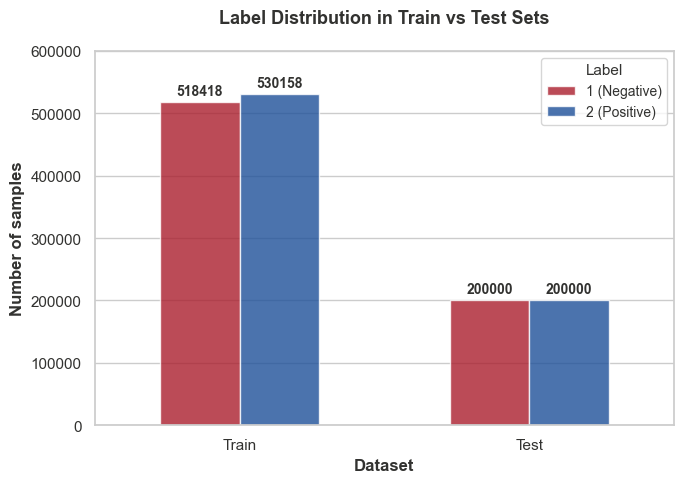

In [ ]:
# Count label frequencies
train_counts = amazon_train['label'].value_counts().sort_index()
test_counts = amazon_test['label'].value_counts().sort_index()

# Build combined DataFrame for train and test sets
df = pd.DataFrame({
    'dataset': ['Train'] * len(train_counts) + ['Test'] * len(test_counts),
    'label': list(train_counts.index) + list(test_counts.index),
    'count': list(train_counts.values) + list(test_counts.values)
})

# Map label numbers to descriptive text
label_map = {1: '1 (Negative)', 2: '2 (Positive)'}
df['label'] = df['label'].map(label_map)

# Plot the bar chart
sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'text.color': '#323230',
    'axes.labelcolor': '#323230',
    'xtick.color': '#323230',
    'ytick.color': '#323230'
})

plt.figure(figsize=(7,5))
sns.barplot(
    data=df,
    x='dataset',
    y='count',
    hue='label',
    palette=['#c1071b', '#094cae'],
    alpha=0.8,
    width=0.55
)

# Add count labels on top of bars
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%d', label_type='edge', fontsize=10, fontweight='bold', padding=3, color='#323230')

# Style and layout adjustments
plt.xlabel('Dataset', fontsize=12, fontweight='bold')
plt.ylabel('Number of samples', fontsize=12, fontweight='bold')
plt.title('Label Distribution in Train vs Test Sets', fontsize=13, fontweight='bold', pad=20)
plt.legend(title='Label', title_fontsize=11, fontsize=10, loc='upper right', frameon=True)

# Fix y-axis range manually
plt.ylim(0, 600000)


# Apply clean spine & background style
ax = plt.gca()
ax.set_facecolor('white')
ax.set_axisbelow(True)
ax.grid(axis='y', color='#e5e5e5', linewidth=0.8, zorder=0)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#cccccc')
plt.gcf().patch.set_facecolor('white')
plt.tight_layout()
plt.show()


#### ii. Number of character & words distribution 

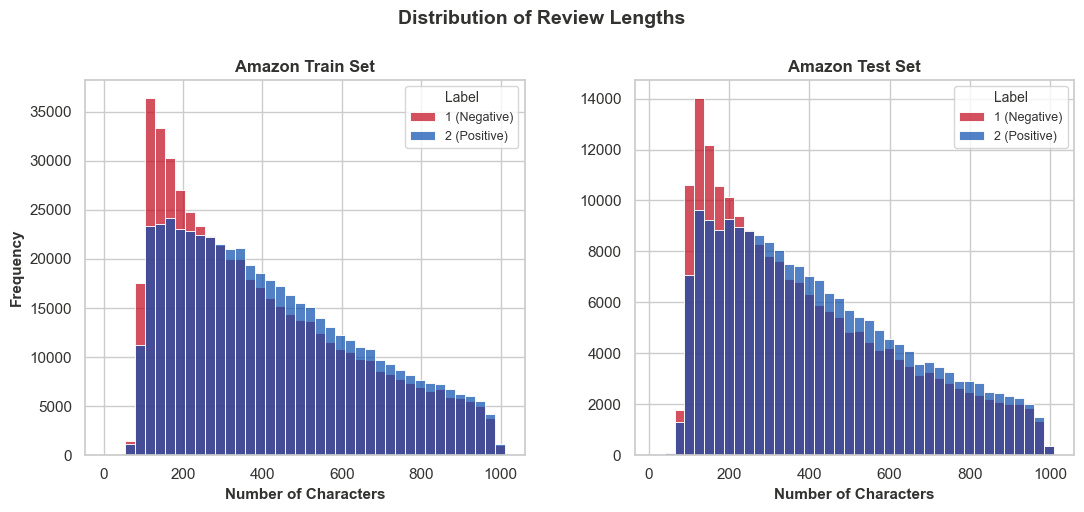

In [ ]:
# Compute review text length
amazon_train['text_len'] = amazon_train['text'].str.len()
amazon_test['text_len'] = amazon_test['text'].str.len()

# Apply Sedna-style theme
sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'text.color': '#323230',
    'axes.labelcolor': '#323230',
    'xtick.color': '#323230',
    'ytick.color': '#323230'
})

# Create subplots for train and test
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11,5))
fig.patch.set_facecolor('white')
fig.suptitle('Distribution of Review Lengths', fontsize=14, fontweight='bold', color='#323230', y=1.02)

# Plot for train set
sns.histplot(
    data=amazon_train, 
    x='text_len', 
    hue='label', 
    bins=40, 
    palette=['#094cae', '#c1071b'], 
    alpha=0.7, 
    ax=ax1
)

ax1.set_title('Amazon Train Set', fontsize=12, fontweight='bold', color='#323230')
ax1.set_xlabel('Number of Characters', fontsize=11, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax1.legend(
    title='Label', 
    labels=['1 (Negative)', '2 (Positive)'],
    title_fontsize=10,
    fontsize=9,
    loc='upper right'
)

# Plot for test set
sns.histplot(
    data=amazon_test, 
    x='text_len', 
    hue='label', 
    bins=40, 
    palette=['#094cae', '#c1071b'], 
    alpha=0.7, 
    ax=ax2
)

ax2.set_title('Amazon Test Set', fontsize=12, fontweight='bold', color='#323230')
ax2.set_xlabel('Number of Characters', fontsize=11, fontweight='bold')
ax2.set_ylabel('', fontsize=11, fontweight='bold')
ax2.legend(
    title='Label', 
    labels=['1 (Negative)', '2 (Positive)'],
    title_fontsize=10,
    fontsize=9,
    loc='upper right'
)

# Layout and spacing adjustments

# Apply clean spine & background style
for ax in [ax1, ax2]:
    ax.set_facecolor('white')
    ax.set_axisbelow(True)
    ax.grid(axis='x', color='#e5e5e5', linewidth=0.8, zorder=0)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#cccccc')
plt.tight_layout()
plt.subplots_adjust(top=0.88, wspace=0.25)
plt.show()


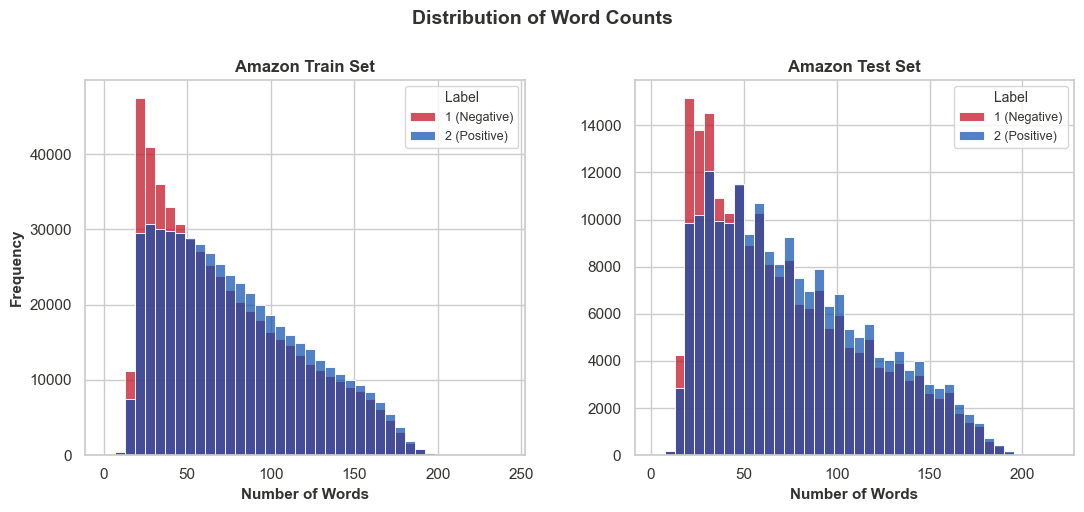

In [ ]:
# Compute number of words in each review
amazon_train['word_count'] = amazon_train['text'].apply(lambda x: len(str(x).split()))
amazon_test['word_count'] = amazon_test['text'].apply(lambda x: len(str(x).split()))

# Apply Sedna-style theme
sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'text.color': '#323230',
    'axes.labelcolor': '#323230',
    'xtick.color': '#323230',
    'ytick.color': '#323230'
})

# Create subplots for train and test
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11,5))
fig.suptitle('Distribution of Word Counts', fontsize=14, fontweight='bold', color='#323230', y=1.02)

# Plot for train set
sns.histplot(
    data=amazon_train,
    x='word_count',
    hue='label',
    bins=40,
    palette=['#094cae', '#c1071b'],
    alpha=0.7,
    ax=ax1
)
ax1.set_title('Amazon Train Set', fontsize=12, fontweight='bold', color='#323230')
ax1.set_xlabel('Number of Words', fontsize=11, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax1.legend(
    title='Label',
    labels=['1 (Negative)', '2 (Positive)'],
    title_fontsize=10,
    fontsize=9,
    loc='upper right'
)

# Plot for test set
sns.histplot(
    data=amazon_test,
    x='word_count',
    hue='label',
    bins=40,
    palette=['#094cae', '#c1071b'],
    alpha=0.7,
    ax=ax2
)
ax2.set_title('Amazon Test Set', fontsize=12, fontweight='bold', color='#323230')
ax2.set_xlabel('Number of Words', fontsize=11, fontweight='bold')
ax2.set_ylabel('', fontsize=11, fontweight='bold')
ax2.legend(
    title='Label',
    labels=['1 (Negative)', '2 (Positive)'],
    title_fontsize=10,
    fontsize=9,
    loc='upper right'
)

# Adjust layout and spacing
plt.tight_layout()
plt.subplots_adjust(top=0.88, wspace=0.25)
plt.show()


#### iii. Average word legnth

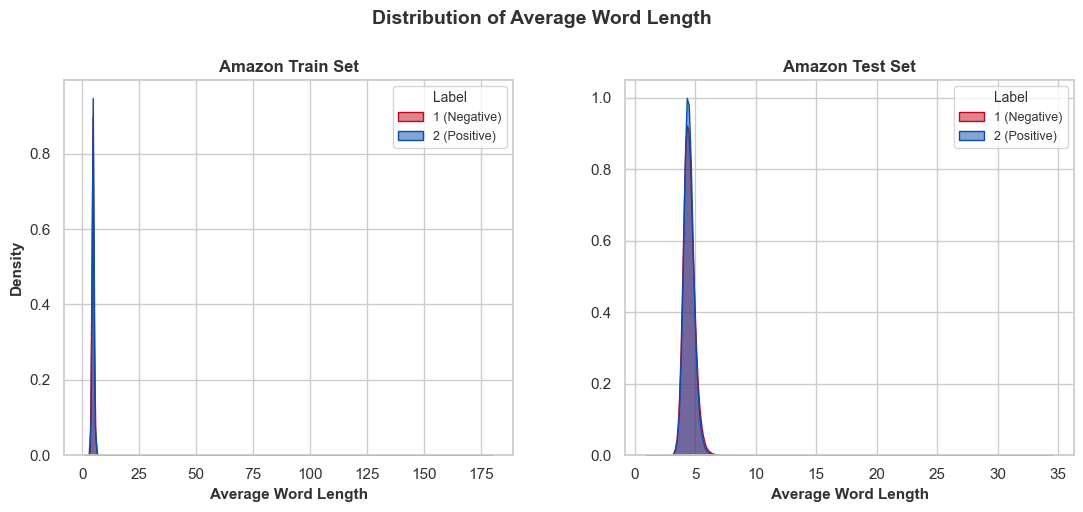

In [ ]:
# Compute average word length per review
def avg_word_len(text):
    words = str(text).split()
    if len(words) == 0:
        return 0
    return np.mean([len(w) for w in words])

amazon_train['avg_word_len'] = amazon_train['text'].apply(avg_word_len)
amazon_test['avg_word_len'] = amazon_test['text'].apply(avg_word_len)

# Apply Sedna-style theme
sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'text.color': '#323230',
    'axes.labelcolor': '#323230',
    'xtick.color': '#323230',
    'ytick.color': '#323230'
})

# Create subplots for train and test
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11,5))
fig.suptitle('Distribution of Average Word Length', fontsize=14, fontweight='bold', color='#323230', y=1.02)

# Plot for train set
sns.kdeplot(
    data=amazon_train,
    x='avg_word_len',
    hue='label',
    fill=True,
    common_norm=False,
    alpha=0.5,
    palette=['#094cae', '#c1071b'],
    ax=ax1
)
ax1.set_title('Amazon Train Set', fontsize=12, fontweight='bold', color='#323230')
ax1.set_xlabel('Average Word Length', fontsize=11, fontweight='bold')
ax1.set_ylabel('Density', fontsize=11, fontweight='bold')
ax1.legend(
    title='Label',
    labels=['1 (Negative)', '2 (Positive)'],
    title_fontsize=10,
    fontsize=9,
    loc='upper right'
)

# Plot for test set
sns.kdeplot(
    data=amazon_test,
    x='avg_word_len',
    hue='label',
    fill=True,
    common_norm=False,
    alpha=0.5,
    palette=['#094cae', '#c1071b'],
    ax=ax2
)
ax2.set_title('Amazon Test Set', fontsize=12, fontweight='bold', color='#323230')
ax2.set_xlabel('Average Word Length', fontsize=11, fontweight='bold')
ax2.set_ylabel('', fontsize=11, fontweight='bold')
ax2.legend(
    title='Label',
    labels=['1 (Negative)', '2 (Positive)'],
    title_fontsize=10,
    fontsize=9,
    loc='upper right'
)

# Adjust layout and spacing
plt.tight_layout()
plt.subplots_adjust(top=0.88, wspace=0.25)
plt.show()


In [ ]:
# Average word legnth check
amazon_train['avg_word_len'].describe()
amazon_train['avg_word_len'].nlargest(50)

759186     180.000000
567141     122.000000
817499     100.000000
866873      60.500000
480062      50.000000
67236       47.800000
629872      31.000000
372563      29.333333
116127      27.720000
937422      26.000000
623607      25.290323
284275      24.000000
408930      21.000000
498465      20.611111
120054      20.111111
911876      18.388889
488889      17.437500
761015      16.833333
363259      16.700000
815386      16.214286
247637      16.000000
41146       15.500000
764055      14.695652
585655      13.866667
865664      13.666667
864775      13.333333
865870      13.333333
669578      13.187500
903167      13.000000
1024696     12.682927
586644      12.650000
611273      12.300000
693604      12.187500
434248      12.177419
804102      12.071429
646867      12.000000
522780      11.916667
471590      11.857143
827514      11.814815
348588      11.562500
413145      11.562500
21830       11.526316
576818      11.500000
382398      11.473684
991667      11.400000
305206    

In [ ]:
# Find indices of reviews with the highest average word length
outlier_idx = amazon_train['avg_word_len'].nlargest(50).index

# Display the corresponding average word length and text content
amazon_train.loc[outlier_idx, ['avg_word_len', 'text']]


,avg_word_len,text
759186,180.000000,Thisis.the.very.first.book.by.her.that.I.had.a...
567141,122.000000,TeTerriffic!Terriffic!Terriffic!Terriffic!Terr...
817499,100.000000,gogogogagagagagagamandiffheuejkuawieuajdsifjhj...
866873,60.500000,threewolveseverhowlingmoonabovemocksme?birdin ...
480062,50.000000,iiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiii...
67236,47.800000,It wa jjhjhgj;lgkkkkhlkjgpouyijoikjjihioyuoiyt...
629872,31.000000,...............................
372563,29.333333,Great Purchase CKVKLJ;JNVKZ;KCVJJVK'ZJXC'VKLZX...
116127,27.720000,&#1050;&#1072;&#1082;&#1080;&#1084; &#1086;&#1...
937422,26.000000,//:practical//logikal//clear explanations//cra...


#### iv. Stop words & Punctuation

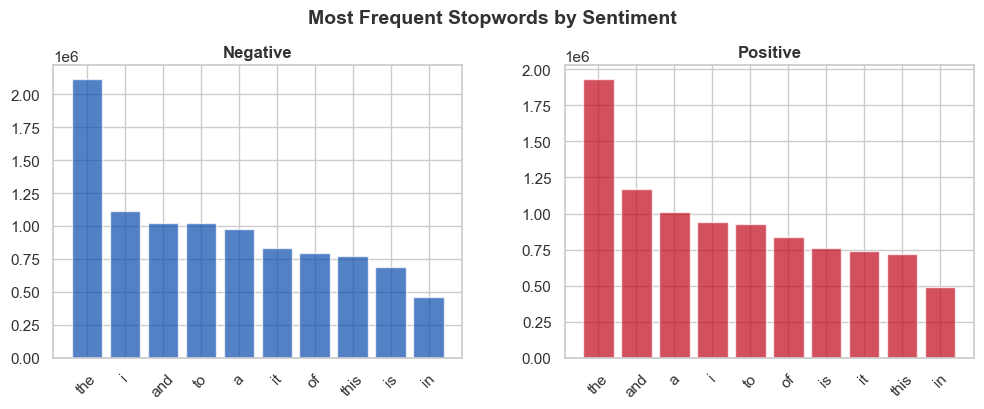

In [ ]:
from nltk.corpus import stopwords
from collections import defaultdict
import re

# Prepare English stopword set
stop = set(stopwords.words('english'))

# Build corpus for a given label
def create_corpus(label):
    corpus = []
    for text in amazon_train[amazon_train['label'] == label]['text']:
        text = str(text).lower()                # Convert to string to avoid NaN errors
        text = re.sub(r'[^a-z\s]', '', text)    # Remove non-alphabetic characters
        corpus += text.split()
    return corpus

# Create corpora for both classes
neg_corpus = create_corpus(1)
pos_corpus = create_corpus(2)

# Plot top 10 frequent stopwords for each label
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))

for corpus, ax, title, color in [
    (neg_corpus, ax1, 'Negative', '#094cae'),
    (pos_corpus, ax2, 'Positive', '#c1071b')
]:
    dic = defaultdict(int)
    for word in corpus:
        if word in stop:
            dic[word] += 1
    top = sorted(dic.items(), key=lambda x: x[1], reverse=True)[:10]
    x, y = zip(*top)
    ax.bar(x, y, color=color, alpha=0.7)
    ax.set_title(title, fontsize=12, fontweight='bold', color='#323230')
    ax.tick_params(axis='x', rotation=45, labelcolor='#323230')
    ax.tick_params(axis='y', labelcolor='#323230')

plt.suptitle('Most Frequent Stopwords by Sentiment', fontsize=14, fontweight='bold', color='#323230', y=1.02)
plt.tight_layout()
plt.subplots_adjust(top=0.88, wspace=0.25)
plt.show()


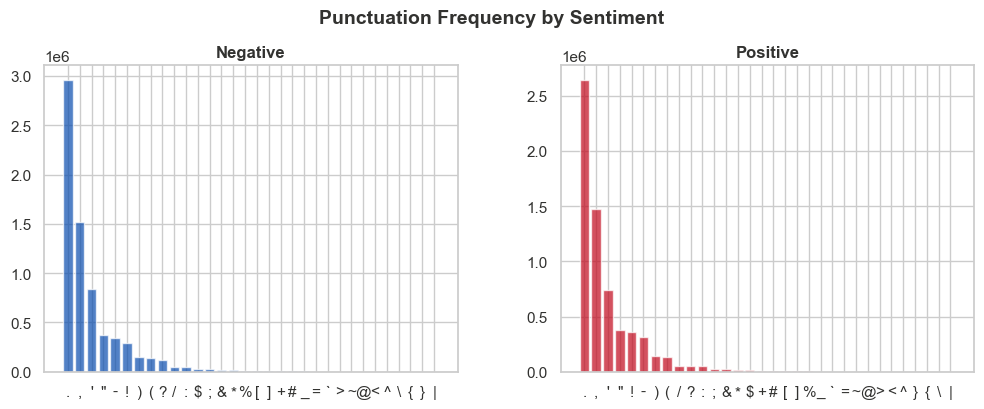

In [ ]:
import string

# Define punctuation characters
special = string.punctuation

# Count punctuation marks in corpus
def count_punct(corpus):
    dic = defaultdict(int)
    for w in corpus:
        if w in special:
            dic[w] += 1
    return dic

# Build corpus for each label
def create_corpus(label):
    corpus = []
    for text in amazon_train[amazon_train['label'] == label]['text']:
        corpus += str(text)
    return corpus

# Build corpora
neg_corpus = create_corpus(1)
pos_corpus = create_corpus(2)

# Count punctuation frequency
dic_neg = count_punct(neg_corpus)
dic_pos = count_punct(pos_corpus)

# Plot punctuation frequency
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))

for dic, ax, color, title in [
    (dic_neg, ax1, '#094cae', 'Negative'),
    (dic_pos, ax2, '#c1071b', 'Positive')
]:
    x, y = zip(*sorted(dic.items(), key=lambda x: x[1], reverse=True))
    ax.bar(x, y, color=color, alpha=0.7)
    ax.set_title(title, fontsize=12, fontweight='bold', color='#323230')
    ax.tick_params(axis='x', labelcolor='#323230')
    ax.tick_params(axis='y', labelcolor='#323230')

plt.suptitle('Punctuation Frequency by Sentiment', fontsize=14, fontweight='bold', color='#323230', y=1.02)
plt.tight_layout()
plt.subplots_adjust(top=0.88, wspace=0.25)
plt.show()


#### v. n-gram Analysis

In [6]:
from sklearn.feature_extraction.text import CountVectorizer

# Extract and visualize top N-grams for sentiment analysis (with progress bars, no emoji)
def N_gram(n=2, top=15):
    # Extract top n-grams with progress bars
    def get_top_ngrams(corpus, n=None, top=None):
        tqdm.pandas(desc=f"Extracting {n}-grams")
        vec = CountVectorizer(ngram_range=(n, n))
        bag = vec.fit_transform(tqdm(corpus, desc=f"Vectorising {n}-gram corpus"))
        sum_words = bag.sum(axis=0)
        words_freq = [(w, sum_words[0, i]) for w, i in vec.vocabulary_.items()]
        return sorted(words_freq, key=lambda x: x[1], reverse=True)[:top]

    # Split by label
    print(f"\nComputing top {n}-grams for negative samples...")
    neg = amazon_train[amazon_train['label'] == 1]['text'].astype(str)
    neg_ngrams = get_top_ngrams(neg, n=n, top=top)
    print("Negative done.\n")

    print(f"Computing top {n}-grams for positive samples...")
    pos = amazon_train[amazon_train['label'] == 2]['text'].astype(str)
    pos_ngrams = get_top_ngrams(pos, n=n, top=top)
    print("Positive done.\n")

    # Convert to DataFrames for optional output
    df_neg = pd.DataFrame(neg_ngrams, columns=[f'{n}-gram', 'Frequency'])
    df_pos = pd.DataFrame(pos_ngrams, columns=[f'{n}-gram', 'Frequency'])

    # Plot both subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    fig.patch.set_facecolor('white')

    for grams, ax, color, title in [
        (neg_ngrams, ax1, '#094cae', f'Negative (Top {n}-grams)'),
        (pos_ngrams, ax2, '#c1071b', f'Positive (Top {n}-grams)')
    ]:
        x, y = zip(*grams)
        sns.barplot(x=list(y), y=list(x), ax=ax, color=color, alpha=0.7)
        ax.set_title(title, fontsize=13, fontweight='bold', color='#323230')
        ax.set_xlabel('Frequency', fontsize=11, fontweight='bold', color='#323230')
        ax.set_ylabel(f'{n}-grams', fontsize=11, fontweight='bold', color='#323230')
        ax.tick_params(axis='x', labelcolor='#323230')
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))
        ax.tick_params(axis='y', labelcolor='#323230', labelsize=12)
        ax.set_facecolor('white')
        ax.set_axisbelow(True)
        ax.grid(axis='x', color='#e5e5e5', linewidth=0.8, zorder=0)
        ax.spines[['top', 'right']].set_visible(False)
        ax.spines[['left', 'bottom']].set_color('#cccccc')

    # Align X-axis range
    for ax in [ax1, ax2]:
        ax.set_xlim(0, max(ax1.get_xlim()[1], ax2.get_xlim()[1]))

    plt.suptitle(f'Most Frequent {n}-grams by Sentiment', fontsize=14, fontweight='bold', color='#323230', y=1.02)
    plt.tight_layout()
    plt.subplots_adjust(top=0.88, wspace=0.3)
    plt.show()

    print("Completed visualization.\n")
    return df_neg, df_pos

In [ ]:
N_gram(2)


Computing top 4-grams for negative samples...


Vectorising 4-gram corpus: 100%|██████████| 518418/518418 [00:46<00:00, 11138.79it/s]


Negative done.

Computing top 4-grams for positive samples...


Vectorising 4-gram corpus: 100%|██████████| 530158/530158 [00:38<00:00, 13687.37it/s]


Positive done.



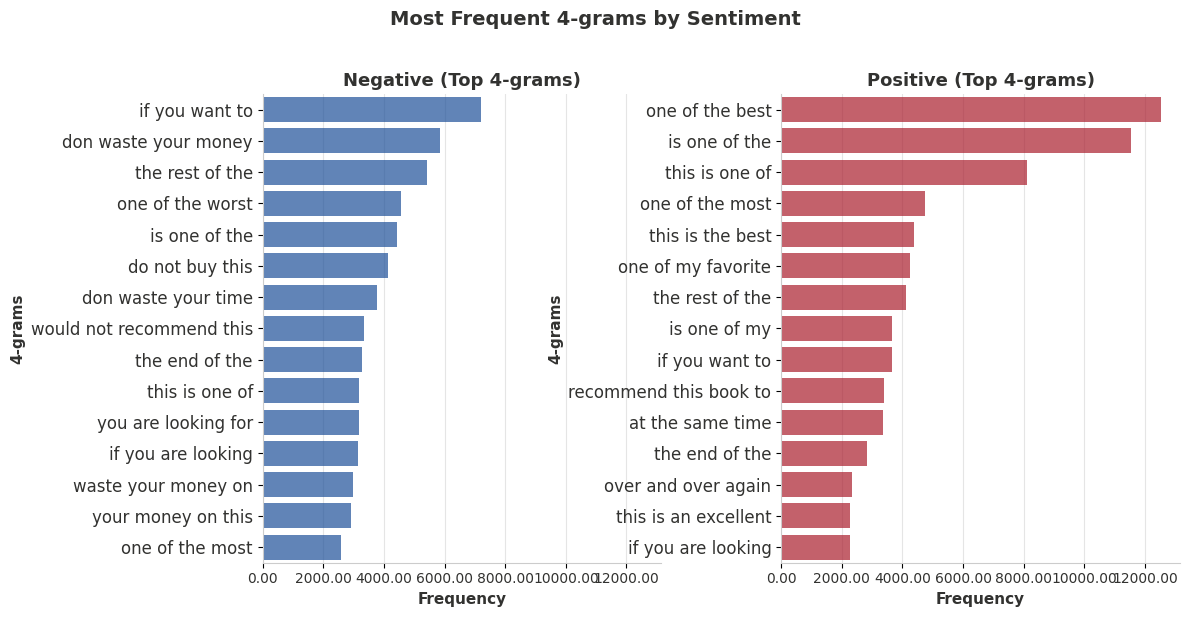

Completed visualization.



(                      4-gram  Frequency
 0             if you want to       7211
 1       don waste your money       5859
 2            the rest of the       5409
 3           one of the worst       4563
 4              is one of the       4419
 5            do not buy this       4124
 6        don waste your time       3780
 7   would not recommend this       3336
 8             the end of the       3288
 9             this is one of       3189
 10       you are looking for       3185
 11        if you are looking       3158
 12       waste your money on       2990
 13        your money on this       2929
 14           one of the most       2592,
                     4-gram  Frequency
 0          one of the best      12529
 1            is one of the      11526
 2           this is one of       8112
 3          one of the most       4757
 4         this is the best       4382
 5       one of my favorite       4260
 6          the rest of the       4121
 7             is one of my    

In [7]:
N_gram(4)

In [ ]:
N_gram(4)

#### vi. TF-IDF

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

# TF-IDF extraction and visualization (Sedna style, with progress bar, no emoji)
def TFIDF_Visual(n=20, ngram_range=(1, 2), save_csv=False, save_path=None):
    # Compute top TF-IDF terms
    def get_top_tfidf_terms(corpus, n=None, ngram_range=(1, 2)):
        tqdm.pandas(desc=f"Calculating TF-IDF {ngram_range}")
        vectorizer = TfidfVectorizer(
            stop_words='english',
            ngram_range=ngram_range,
            max_df=0.9,
            min_df=5
        )
        X = vectorizer.fit_transform(tqdm(corpus, desc="Vectorising corpus"))
        feature_names = np.array(vectorizer.get_feature_names_out())
        tfidf_means = np.asarray(X.mean(axis=0)).ravel()
        top_indices = tfidf_means.argsort()[::-1][:n]
        return list(zip(feature_names[top_indices], tfidf_means[top_indices]))

    # Split by sentiment
    print(f"\nComputing TF-IDF for range {ngram_range} ...")
    neg = amazon_train[amazon_train['label'] == 1]['text'].astype(str)
    pos = amazon_train[amazon_train['label'] == 2]['text'].astype(str)

    print("Negative samples:")
    neg_tfidf = get_top_tfidf_terms(neg, n=n, ngram_range=ngram_range)
    print("Negative done.\n")

    print("Positive samples:")
    pos_tfidf = get_top_tfidf_terms(pos, n=n, ngram_range=ngram_range)
    print("Positive done.\n")

    # Convert to DataFrame
    df_neg = pd.DataFrame(neg_tfidf, columns=['Term', 'TF-IDF'])
    df_pos = pd.DataFrame(pos_tfidf, columns=['Term', 'TF-IDF'])

    # Plot TF-IDF bars
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    fig.patch.set_facecolor('white')

    for tfidf_terms, ax, color, title in [
        (neg_tfidf, ax1, '#094cae', 'Negative (Top TF-IDF terms)'),
        (pos_tfidf, ax2, '#c1071b', 'Positive (Top TF-IDF terms)')
    ]:
        x, y = zip(*tfidf_terms)
        sns.barplot(x=list(y), y=list(x), ax=ax, color=color, alpha=0.7)
        ax.set_title(title, fontsize=13, fontweight='bold', color='#323230')
        ax.set_xlabel('TF-IDF Weight', fontsize=11, fontweight='bold', color='#323230')
        ax.set_ylabel('', fontsize=11, fontweight='bold', color='#323230')
        ax.tick_params(axis='x', labelcolor='#323230')
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))
        ax.tick_params(axis='y', labelcolor='#323230', labelsize=12)
        ax.set_facecolor('white')
        ax.set_axisbelow(True)
        ax.grid(axis='x', color='#e5e5e5', linewidth=0.8, zorder=0)
        ax.spines[['top', 'right']].set_visible(False)
        ax.spines[['left', 'bottom']].set_color('#cccccc')

    # Align x-axis range
    for ax in [ax1, ax2]:
        ax.set_xlim(0, max(ax1.get_xlim()[1], ax2.get_xlim()[1]))

    plt.suptitle(f'Top {n} TF-IDF Terms by Sentiment ({ngram_range[0]}-{ngram_range[1]} grams)', 
                 fontsize=14, fontweight='bold', color='#323230', y=1.02)
    plt.tight_layout()
    plt.subplots_adjust(top=0.88, wspace=0.3)
    plt.show()

    # Optionally save CSV
    if save_csv:
        if save_path is None:
            save_path = f"tfidf_output_{ngram_range[0]}_{ngram_range[1]}gram.csv"
        combined_df = pd.concat([
            df_neg.assign(Label='Negative'),
            df_pos.assign(Label='Positive')
        ])
        combined_df.to_csv(save_path, index=False, encoding='utf-8-sig')
        print(f"Saved TF-IDF results to: {save_path}")

    print("TF-IDF visualization completed.\n")
    return df_neg, df_pos


In [ ]:
# ── TF-IDF Visualization (Top 10, bigram) ──────────────────────
df_neg_tfidf, df_pos_tfidf = TFIDF_Visual(n=10, ngram_range=(1, 2))


Computing TF-IDF vectors for all samples...


100%|██████████| 1048576/1048576 [00:50<00:00, 20668.32it/s]


TF-IDF matrix shape: (1048576, 1004640)
Applying LSA (2D Truncated SVD)...
LSA projection shape: (1048576, 2) (0.30% variance retained)


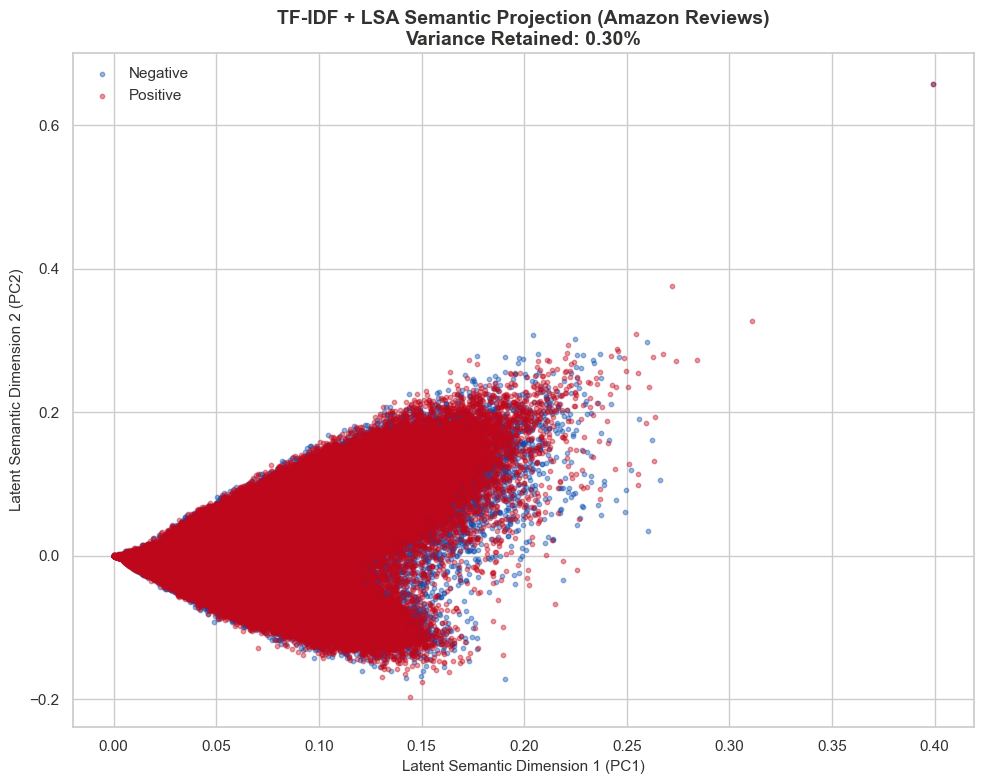

In [17]:
# Compute TF-IDF vectors for all samples
print("Computing TF-IDF vectors for all samples...")
vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    max_df=0.9,
    min_df=5
)

tqdm.pandas(desc="Vectorising corpus")
X_tfidf = vectorizer.fit_transform(tqdm(amazon_train['text'].astype(str)))
y = amazon_train['label'].values
print(f"TF-IDF matrix shape: {X_tfidf.shape}")

# Apply LSA (Truncated SVD) for 2D projection
print("Applying LSA (2D Truncated SVD)...")
lsa = TruncatedSVD(n_components=2, random_state=42)
X_lsa = lsa.fit_transform(X_tfidf)
explained_var = lsa.explained_variance_ratio_.sum() * 100
print(f"LSA projection shape: {X_lsa.shape} ({explained_var:.2f}% variance retained)")

# Scatter plot visualization
plt.figure(figsize=(10, 8))
palette = {1: "#094cae", 2: "#c1071b"}  # Blue=Negative, Red=Positive

plt.scatter(
    X_lsa[y == 1, 0], X_lsa[y == 1, 1],
    color=palette[1], alpha=0.4, s=10, label='Negative'
)
plt.scatter(
    X_lsa[y == 2, 0], X_lsa[y == 2, 1],
    color=palette[2], alpha=0.4, s=10, label='Positive'
)

plt.title(
    f"TF-IDF + LSA Semantic Projection (Amazon Reviews)\nVariance Retained: {explained_var:.2f}%",
    fontsize=14, fontweight='bold', color='#323230'
)
plt.xlabel("Latent Semantic Dimension 1 (PC1)", fontsize=11, color='#323230')
plt.ylabel("Latent Semantic Dimension 2 (PC2)", fontsize=11, color='#323230')
plt.legend(frameon=False)
plt.tight_layout()

# Save the figure
# save_path = r"F:\Warwick Module\ST415\note\tfidf_lsa_projection.png"
# plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()


#### vii. Glove

Loading GloVe embeddings from: F:\Warwick Module\ST415\Code & Dependencies\glove.6B.100d.txt


Loading GloVe: 0it [00:00, ?it/s]

Loaded 400,000 word vectors.
Using 20972 samples for visualisation...


Encoding sentences:   0%|          | 0/20972 [00:00<?, ?it/s]

Sentence embedding shape: (20972, 100)
Reducing dimension with PCA ...


Encoding sentences:  86%|████████▌ | 18071/20972 [04:20<00:41, 69.47it/s]   


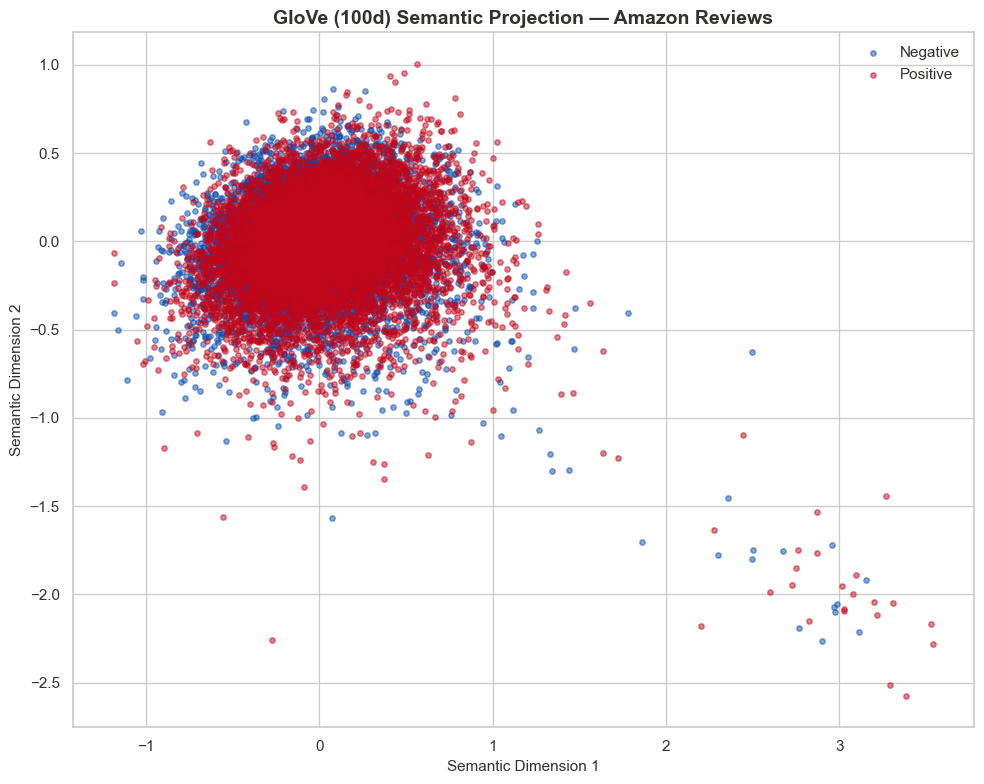

In [22]:
# === GloVe Semantic Projection (Amazon Reviews) ===
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from tqdm.auto import tqdm
import sys
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import re

# Load pretrained GloVe 100d embeddings
glove_path = r"F:\Warwick Module\ST415\Code & Dependencies\glove.6B.100d.txt"
print(f"Loading GloVe embeddings from: {glove_path}")

embedding_dict = {}
with open(glove_path, 'r', encoding='utf8') as f:
    for line in tqdm(
        f,
        desc="Loading GloVe",
        leave=False,
        dynamic_ncols=True,
        file=sys.stdout
    ):
        values = line.strip().split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        embedding_dict[word] = vector

print(f"Loaded {len(embedding_dict):,} word vectors.")

# Convert sentence to average word vector
def sentence_to_vec(text, embedding_dict, dim=100):
    words = re.findall(r"\b[a-zA-Z']+\b", str(text).lower())
    vectors = [embedding_dict[w] for w in words if w in embedding_dict]
    if len(vectors) == 0:
        return np.zeros(dim)
    return np.mean(vectors, axis=0)

# Sample a subset for visualization
sample_frac = 0.02
sample_df = amazon_train.sample(frac=sample_frac, random_state=42)
print(f"Using {len(sample_df)} samples for visualisation...")

X_glove = np.vstack([
    sentence_to_vec(t, embedding_dict)
    for t in tqdm(
        sample_df['text'],
        desc="Encoding sentences",
        leave=False,
        dynamic_ncols=True,
        file=sys.stdout
    )
])
y = sample_df['label'].values
print(f"Sentence embedding shape: {X_glove.shape}")

# Dimensionality reduction (PCA or t-SNE)
use_tsne = False
print(f"Reducing dimension with {'t-SNE' if use_tsne else 'PCA'} ...")

if use_tsne:
    reducer = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
else:
    reducer = PCA(n_components=2, random_state=42)

X_2d = reducer.fit_transform(X_glove)

# Scatter plot
plt.figure(figsize=(10, 8))
palette = {1: "#094cae", 2: "#c1071b"}  # Blue=Negative, Red=Positive

plt.scatter(X_2d[y == 1, 0], X_2d[y == 1, 1], color=palette[1], alpha=0.5, s=15, label='Negative')
plt.scatter(X_2d[y == 2, 0], X_2d[y == 2, 1], color=palette[2], alpha=0.5, s=15, label='Positive')

plt.title("GloVe (100d) Semantic Projection — Amazon Reviews", fontsize=14, fontweight='bold', color='#323230')
plt.xlabel("Semantic Dimension 1", fontsize=11, color='#323230')
plt.ylabel("Semantic Dimension 2", fontsize=11, color='#323230')
plt.legend(frameon=False)
plt.tight_layout()

# Save figure (optional)
# save_path = r"F:\Warwick Module\ST415\note\glove_semantic_projection.png"
# plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()


### 3. Data Cleaning

#### i. Removing url

Detection

In [5]:
# Improved regex pattern using non-capturing group
url_pattern = re.compile(r'(?:https?://\S+|www\.\S+)')

# Copy datasets
train_check_url = amazon_train.copy()
test_check_url = amazon_test.copy()

# Detect samples containing URLs
train_check_url = train_check_url[train_check_url['text'].str.contains(url_pattern, na=False)]
test_check_url = test_check_url[test_check_url['text'].str.contains(url_pattern, na=False)]

# Print statistics
print(f"Training set samples containing URLs: {len(train_check_url)}")
print(f"Test set samples containing URLs: {len(test_check_url)}\n")

# Highlight URLs with blue underline for terminal display
def highlight_urls(text):
    BLUE_UNDERLINE = "\033[94m\033[4m"
    RESET = "\033[0m"
    return re.sub(url_pattern, lambda m: f"{BLUE_UNDERLINE}{m.group(0)}{RESET}", text)

# Pretty-print samples with URLs
def preview_url_examples(df, title, n=5):
    print(f"\n===== {title} (showing {n} samples) =====\n")
    for idx, text in df['text'].head(n).items():
        text = re.sub(r'\s+', ' ', str(text).strip())
        text = (text[:400] + '...') if len(text) > 400 else text
        text = highlight_urls(text)
        print(f"[Index: {idx}]")
        print(text)
        print("-" * 120)

# Display results
preview_url_examples(train_check_url, "Train samples containing URLs", n=5)
preview_url_examples(test_check_url, "Test samples containing URLs", n=5)


Training set samples containing URLs: 1552
Test set samples containing URLs: 603


===== Train samples containing URLs (showing 5 samples) =====

[Index: 193]
As someone who has been practicing Chinese Medicine for 16 years in San Diego (www.bodymindwellnesscenter.com), I find this book an excellent resource for anyone who wants and in dept primer into the theoretical basis and practical application of a system of medicine that originates in the Chinese philosophy that emphasizes the natural balance found in Nature and agriculture.
------------------------------------------------------------------------------------------------------------------------
[Index: 436]
Since writing my review of JFK: THE LAST DISSENTING WITNESS in 1998, I have been able to have my 35-page article - "Jean Hill -The Lady in Red" - included in Clint Bradford's JFK Assassination website. The address is: http://www.jfk-info.com/sitemap1.htm (scroll down for title).
------------------------------------------------

Removal

In [6]:
# Create copies to avoid modifying original data
train_no_url = amazon_train.copy()
test_no_url = amazon_test.copy()

# Define function to remove URLs
def remove_URL(text):
    if not isinstance(text, str):
        return text
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    return url_pattern.sub('', text)

# Apply cleaning to the copies
train_no_url['text'] = train_no_url['text'].apply(remove_URL)
test_no_url['text'] = test_no_url['text'].apply(remove_URL)

# Confirm completion
print("URLs have been removed.")


URLs have been removed.


#### ii. Remobing HTML tags

Detection

In [7]:
# Regex for detecting HTML tags
html_pattern = re.compile(r'<.*?>')

# Create copies
train_check_html = train_no_url.copy()
test_check_html = test_no_url.copy()

# Find samples still containing HTML tags
train_check_html = train_check_html[train_check_html['text'].str.contains(html_pattern, na=False)]
test_check_html = test_check_html[test_check_html['text'].str.contains(html_pattern, na=False)]

# Print statistics
print(f"Number of samples still containing HTML tags in training set: {len(train_check_html)}")
print(f"Number of samples still containing HTML tags in test set: {len(test_check_html)}\n")

# Highlight HTML tags (cyan underline)
def highlight_html(text):
    BLUE_UNDERLINE = "\033[96m\033[4m"
    RESET = "\033[0m"
    return re.sub(html_pattern, lambda m: f"{BLUE_UNDERLINE}{m.group(0)}{RESET}", text)

# Pretty-print detected samples
def preview_html_examples(df, title, n=5):
    print(f"\n===== {title} (showing {n} samples) =====\n")
    for idx, text in df['text'].head(n).items():
        text = re.sub(r'\s+', ' ', str(text).strip())
        text = (text[:400] + '...') if len(text) > 400 else text
        text = highlight_html(text)
        print(f"[Index: {idx}]")
        print(text)
        print("-" * 120)

# Display results
if len(train_check_html) > 0:
    preview_html_examples(train_check_html, "Train samples containing HTML tags", n=5)
else:
    print("Training set is fully cleaned from HTML tags.")

if len(test_check_html) > 0:
    preview_html_examples(test_check_html, "Test samples containing HTML tags", n=5)
else:
    print("Test set is fully cleaned from HTML tags.")


Number of samples still containing HTML tags in training set: 500
Number of samples still containing HTML tags in test set: 189


===== Train samples containing HTML tags (showing 5 samples) =====

[Index: 950]
I loved this movie. It was hilarious and Sandler's fans especially will be cracking themselves up. I must admit that it is very crude at parts, so although the cover looks appealing for youngsters, it probably isn't suitable for the young ones. Although, I must admit that a lot of the jokes will go right over their heads.The message is good and the overall story has a message. I cried for Whitey, ...
------------------------------------------------------------------------------------------------------------------------
[Index: 1653]
Half the book (literally) is quotes. The rest, a bunch of touchy-feely, quite unmitigated flapdoodle. In my opinion, anyways. Considering how easily and cheaply quotation dictionaries can be had these days, I'd say, go to the source <g>, and just get

Removal

In [8]:
# Create copies
train_no_html = train_no_url.copy()
test_no_html = test_no_url.copy()

# Define function to remove HTML tags
def remove_html(text):
    if not isinstance(text, str):
        return text
    html_pattern = re.compile(r'<.*?>')
    return html_pattern.sub('', text)

# Apply cleaning to new copies
train_no_html['text'] = train_no_html['text'].apply(remove_html)
test_no_html['text'] = test_no_html['text'].apply(remove_html)

# Verify removal
print("HTML tags have been removed. Examples:")
print(train_no_html['text'].head(5))


HTML tags have been removed. Examples:
0    This sound track was beautiful! It paints the ...
1    I'm reading a lot of reviews saying that this ...
2    This soundtrack is my favorite music of all ti...
3    I truly like this soundtrack and I enjoy video...
4    If you've played the game, you know how divine...
Name: text, dtype: object


#### iii. Removing emoji

Detection

In [9]:
# Define emoji pattern
emoji_pattern = re.compile(
    "[" 
    u"\U0001F600-\U0001F64F"  # Emoticons
    u"\U0001F300-\U0001F5FF"  # Symbols & pictographs
    u"\U0001F680-\U0001F6FF"  # Transport & map symbols
    u"\U0001F1E0-\U0001F1FF"  # Flags
    u"\U00002702-\U000027B0"  # Dingbats
    u"\U000024C2-\U0001F251"  # Enclosed characters
    "]+", flags=re.UNICODE
)

# Create copies from train_no_html / test_no_html
train_check_emoji = train_no_html.copy()
test_check_emoji = test_no_html.copy()

# Find samples still containing emojis
train_check_emoji = train_check_emoji[train_check_emoji['text'].str.contains(emoji_pattern, na=False)]
test_check_emoji = test_check_emoji[test_check_emoji['text'].str.contains(emoji_pattern, na=False)]

# Show statistics
print(f"Number of samples containing emojis in training set: {len(train_check_emoji)}")
print(f"Number of samples containing emojis in test set: {len(test_check_emoji)}\n")

# Highlight emojis with yellow background
def highlight_emoji(text):
    YELLOW = "\033[43m\033[30m"
    RESET = "\033[0m"
    return re.sub(emoji_pattern, lambda m: f"{YELLOW}{m.group(0)}{RESET}", text)

# Pretty-print detected samples
def preview_emoji_examples(df, title, n=5):
    print(f"\n===== {title} (showing {n} samples) =====\n")
    for idx, text in df['text'].head(n).items():
        text = re.sub(r'\s+', ' ', str(text).strip())
        text = (text[:400] + '...') if len(text) > 400 else text
        text = highlight_emoji(text)
        print(f"[Index: {idx}]")
        print(text)
        print("-" * 120)

# Display results
if len(train_check_emoji) > 0:
    preview_emoji_examples(train_check_emoji, "Train samples containing emojis", n=5)
else:
    print("Training set is fully cleaned from emojis.")

if len(test_check_emoji) > 0:
    preview_emoji_examples(test_check_emoji, "Test samples containing emojis", n=5)
else:
    print("Test set is fully cleaned from emojis.")


Number of samples containing emojis in training set: 3485
Number of samples containing emojis in test set: 0


===== Train samples containing emojis (showing 5 samples) =====

[Index: 123]
LO QUE PENSE QUE NO ME INTERESABA SABER SOBRE EL BOX Y SUS CAMPEONES...PERO ME CAUTIVO Y LO LEI HASTA EL FINAL !AHORA SI PUEDO DISCUTIR DE BOX CON MI ESPOSO Y MIS CU脩ADOS...隆Y HASTA CON MI SUEGRO, QUE ES EX BOXEADOR !
------------------------------------------------------------------------------------------------------------------------
[Index: 545]
In this experimental album, B茅langer shows his own dark & hidden garden. Obviously describing his fights against a depressive lifestyle and his deepest reflexions in his previous album (Rver Mieux - wich totally impressed me), he comes back with an exclusive musical and lyrical style mostly expressing how he concieves life as a constant fight (analogy: boxe). All songs bearing numbers instead of t...
-------------------------------------------------------

Removal

In [10]:
# Create copies
train_no_emoji = train_no_html.copy()
test_no_emoji = test_no_html.copy()

# Define function to remove emojis
def remove_emoji(text):
    if not isinstance(text, str):
        return text
    emoji_pattern = re.compile(
        "[" 
        u"\U0001F600-\U0001F64F"  # Emoticons
        u"\U0001F300-\U0001F5FF"  # Symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # Transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # Flags
        u"\U00002702-\U000027B0"  # Dingbats
        u"\U000024C2-\U0001F251"  # Enclosed characters
        "]+", flags=re.UNICODE)
    return emoji_pattern.sub('', text)

# Apply cleaning to the copies
train_no_emoji['text'] = train_no_emoji['text'].apply(remove_emoji)
test_no_emoji['text'] = test_no_emoji['text'].apply(remove_emoji)

# Verify cleaning results
pd.set_option('display.max_colwidth', None)
print("Emojis have been removed.")


Emojis have been removed.


#### iv. Cleaning garbled text

In [11]:
import re
from tqdm import tqdm

def glitch_clean(df, columns):

    # Define allowed characters (remove all others)
    allowed_pattern = re.compile(r"[^A-Za-z0-9\s.,!?;:'\"()\[\]\-\/&%$#@*+=_~`’“”]")

    # Create a copy of the original DataFrame
    cleaned_df = df.copy()
    print(f"Starting glitch clean for columns: {columns}")

    total_changed = 0
    change_examples = []

    # Loop through each column to clean
    for col in columns:
        if col not in cleaned_df.columns:
            print(f"⚠️ Column '{col}' not found, skipping.")
            continue

        # Convert column to list of strings
        original_texts = cleaned_df[col].astype(str).tolist()
        cleaned_texts = []

        # Clean each text entry with regex
        for text in tqdm(original_texts, desc=f"Cleaning '{col}'", ncols=100):
            cleaned_text = allowed_pattern.sub("", text)
            cleaned_text = re.sub(r"\s+", " ", cleaned_text).strip()
            cleaned_texts.append(cleaned_text)

        # Count how many values changed after cleaning
        changed_mask = [orig != clean for orig, clean in zip(original_texts, cleaned_texts)]
        changed_count = sum(changed_mask)
        total_changed += changed_count

        # Update cleaned values in DataFrame
        cleaned_df[col] = cleaned_texts
        print(f"✅ Finished cleaning column: '{col}' — {changed_count:,} modified ({changed_count/len(df)*100:.2f}%)")

        # Collect top 10 sample changes
        examples = [(o, c) for o, c in zip(original_texts, cleaned_texts) if o != c][:10]
        if examples:
            print(f"\n Top 10 changed examples for '{col}':\n" + "-"*60)
            for i, (before, after) in enumerate(examples, 1):
                print(f"{i}. Before: {before}\n   After : {after}\n")

    # Final summary
    print(f"Glitch cleaning complete. Total modified rows across all columns: {total_changed:,}/{len(df)} ({total_changed/len(df)*100:.2f}%)")
    return cleaned_df


In [12]:
train_garbled_clean = glitch_clean(train_no_emoji, ["title", "text"])

Starting glitch clean for columns: ['title', 'text']


Cleaning 'title': 100%|███████████████████████████████| 1048576/1048576 [00:01<00:00, 672367.80it/s]


✅ Finished cleaning column: 'title' — 1,134 modified (0.11%)

 Top 10 changed examples for 'title':
------------------------------------------------------------
1. Before: Squeem:> A Combination of Scream and Squeeze?
   After : Squeem: A Combination of Scream and Squeeze?

2. Before: La reencarnaci贸n vista por un cient铆fico
   After : La reencarnacin vista por un cientfico

3. Before: 2月5日
   After : 25

4. Before: =^)
   After : =)

5. Before: La mejor pel铆cula de Moore
   After : La mejor pelcula de Moore

6. Before: Great Early Mot枚rhead
   After : Great Early Motrhead

7. Before: Ich wei脽 ja nicht !
   After : Ich wei ja nicht !

8. Before: Tr茅s Bien C茅line
   After : Trs Bien Cline

9. Before: C茅line is at her best in French!
   After : Cline is at her best in French!

10. Before: OH MY GOD GET THIS ALUBUM>>>ALMOST AS GOOD AS THE 1ST!!
   After : OH MY GOD GET THIS ALUBUMALMOST AS GOOD AS THE 1ST!!



Cleaning 'text': 100%|█████████████████████████████████| 1048576/1048576 [00:14<00:00, 74301.22it/s]


✅ Finished cleaning column: 'text' — 4,389 modified (0.42%)

 Top 10 changed examples for 'text':
------------------------------------------------------------
1. Before: This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I have ever played it has the best music! It backs away from crude keyboarding and takes a fresher step with grate guitars and soulful orchestras. It would impress anyone who cares to listen! ^_^
   After : This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I have ever played it has the best music! It backs away from crude keyboarding and takes a fresher step with grate guitars and soulful orchestras. It would impress anyone who cares to listen! _

2. Before: I am quite sure any

In [13]:
test_garbled_clean = glitch_clean(test_no_emoji, ["title", "text"])

Starting glitch clean for columns: ['title', 'text']


Cleaning 'title': 100%|█████████████████████████████████| 400000/400000 [00:00<00:00, 611156.22it/s]


✅ Finished cleaning column: 'title' — 466 modified (0.12%)

 Top 10 changed examples for 'title':
------------------------------------------------------------
1. Before: :\
   After : :

2. Before: Colleen - Colleen Et Les Botes Ã Musique
   After : Colleen - Colleen Et Les Botes Musique

3. Before: definitely the best horror\suspense book I know
   After : definitely the best horrorsuspense book I know

4. Before: lo mejor del cine espaÃ±ol
   After : lo mejor del cine espaol

5. Before: moby = genius Â¿? why Â¿?
   After : moby = genius ? why ?

6. Before: MATRIX FOREVER!! OUT OF PRINT> AGAIN!!!!!
   After : MATRIX FOREVER!! OUT OF PRINT AGAIN!!!!!

7. Before: So far - trÃ¨s bon
   After : So far - trs bon

8. Before: <*** This movie is BAD! ****>
   After : *** This movie is BAD! ****

9. Before: Excelente, como todos los libros de Ã©l.
   After : Excelente, como todos los libros de l.

10. Before: Very awesome<3
   After : Very awesome3



Cleaning 'text': 100%|███████████████████████████████████| 400000/400000 [00:05<00:00, 73625.78it/s]


✅ Finished cleaning column: 'text' — 3,015 modified (0.75%)

 Top 10 changed examples for 'text':
------------------------------------------------------------
1. Before: Y ESTE LIBRO ESTÃ ESPLÃNDIDO !Lo disfrutas, lo puedes usar como obra de consultaNos trae LAS HISTORIA DE LOS BOXEADORES MÃS BRILLANTES, DE LOS CAMPEONES DURANTE CIEN AÃOS !!Si te gusta el box...Â¡NO TE LO PIERDAS !
   After : Y ESTE LIBRO EST ESPLNDIDO !Lo disfrutas, lo puedes usar como obra de consultaNos trae LAS HISTORIA DE LOS BOXEADORES MS BRILLANTES, DE LOS CAMPEONES DURANTE CIEN AOS !!Si te gusta el box...NO TE LO PIERDAS !

2. Before: A clichÃ©d storyline based on the classic Cyrano de Bergerac, this book reads like a rookie novel written by someone who has a knowledge and passion for Italian culture and cuisine, but little experience in developing a story. I can understand Bruno and his passion for cooking, but have no clue as to his passion for Laura. It seems to be primarily based on her being a blonde A

#### iv. Deduplication

In [14]:
import re
from tqdm import tqdm
from collections import Counter

def deduplicate(df, columns=["title", "text"], window=10, repeat_threshold=3):

    # Internal function to deduplicate characters and words
    def _dedup_text(text):
        if not isinstance(text, str):
            return text

        # Limit continuous punctuation to 2
        text = re.sub(r'([!?.,])\1{2,}', r'\1\1', text)
        # Limit same letter repeated ≥3 to 2
        text = re.sub(r'([a-zA-Z])\1{2,}', r'\1\1', text)
        # Remove consecutive duplicate words
        text = re.sub(r'\b(\w+)( \1\b)+', r'\1', text)

        words = text.split()
        cleaned = []
        recent = []

        # Sliding window to detect repeated words
        for w in words:
            recent.append(w)
            if len(recent) > window:
                recent.pop(0)
            freq = Counter([r.lower() for r in recent])
            if freq[w.lower()] >= repeat_threshold:
                continue
            cleaned.append(w)

        text = " ".join(cleaned)
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    # Apply progress bar for pandas
    tqdm.pandas(desc="Deduplicating")

    dedup_df = df.copy()
    total_changed = 0
    examples = []

    # Process each target column
    for col in columns:
        before = dedup_df[col].astype(str).tolist()
        after = dedup_df[col].progress_apply(_dedup_text)
        dedup_df[col] = after

        # Count modified rows
        changed_mask = [b != a for b, a in zip(before, after)]
        changed_count = sum(changed_mask)
        total_changed += changed_count

        # Collect first 10 modified examples
        for b, a in zip(before, after):
            if b != a:
                examples.append((col, b, a))
            if len(examples) >= 10:
                break

        print(f"{col} cleaned, modified {changed_count:,}/{len(df)} rows ({changed_count/len(df)*100:.2f}%)")

    print(f"\nTotal modified rows: {total_changed:,}/{len(df)} ({total_changed/len(df)*100:.2f}%)")

    # Show first 10 examples
    if examples:
        print("\nTop 10 modified examples:\n" + "-"*60)
        for i, (col, b, a) in enumerate(examples[:10], 1):
            print(f"{i}. [{col}] Before: {b}\n   After : {a}\n")

    return dedup_df


In [15]:
deduplicate_train = deduplicate(train_garbled_clean, ["title", "text"])

print("\ndeduplicate_train completed, total {:,} samples.".format(len(deduplicate_train)))

deduplicate_train


Deduplicating: 100%|██████████| 1048576/1048576 [00:14<00:00, 74704.88it/s]


title cleaned, modified 97,669/1048576 rows (9.31%)


Deduplicating: 100%|██████████| 1048576/1048576 [05:07<00:00, 3414.88it/s]


text cleaned, modified 386,210/1048576 rows (36.83%)

Total modified rows: 483,879/1048576 (46.15%)

Top 10 modified examples:
------------------------------------------------------------
1. [title] Before: i liked this album more then i thought i would
   After : i liked this album more then i thought would

2. [title] Before: Problem with charging smaller AAAs
   After : Problem with charging smaller AAs

3. [title] Before: happy with it...but
   After : happy with it..but

4. [title] Before: Is this great TV??? You bet it is
   After : Is this great TV?? You bet it is

5. [title] Before: Sooo JAMMIN', too trill
   After : Soo JAMMIN', too trill

6. [title] Before: Thank you for Releasing it!!!!!
   After : Thank you for Releasing it!!

7. [title] Before: YES!!!
   After : YES!!

8. [title] Before: DDR is cooool!
   After : DDR is cool!

9. [title] Before: I got fooled...
   After : I got fooled..

10. [title] Before: I got fooled...
   After : I got fooled..


deduplicate_train comp

,label,title,text
0,2,Stuning even for the non-gamer,This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I have ever played it has the best music! It backs away from crude keyboarding and takes a fresher step with grate guitars and soulful orchestras. It would impress anyone who cares to listen! _
1,2,The best soundtrack ever to anything.,"I'm reading a lot of reviews saying that this is the best 'game soundtrack' and I figured that I'd write a review to disagree a bit. This in my opinino is Yasunori Mitsuda's ultimate masterpiece. The music is timeless and I'm been listening to it for years now and its beauty simply refuses to fade.The price tag on this is pretty staggering I must say, but if you are going to buy any cd for this much money, this is the only one that I feel would be worth every penny."
2,2,Amazing!,"This soundtrack is my favorite music of all time, hands down. The intense sadness of ""Prisoners of Fate"" (which means all the more if you've played the game) and hope in ""A Distant Promise"" and ""Girl who Stole the Star"" have been an important inspiration to me personally throughout my teen years. The higher energy tracks like ""Chrono Cross ~ Time's Scar~"", ""Time of the Dreamwatch"", and ""Chronomantique"" (indefinably remeniscent of Chrono Trigger) are all absolutely superb as well.This soundtrack is amazing music, probably the best of this composer's work (I haven't heard the Xenogears soundtrack, so I can't say for sure), and even if you've never played the game, it would be worth twice the price to buy it.I wish I could give it 6 stars."
3,2,Excellent Soundtrack,"I truly like this soundtrack and I enjoy video game music. I have played this game and most of the music on here I enjoy and it's truly relaxing and peaceful.On disk one. my favorites are Scars Of Time, Between Life and Death, Forest Of Illusion, Fortress of Ancient Dragons, Lost Fragment, and Drowned Valley.Disk Two: The Draggons, Galdorb - Home, Chronomantique, Prisoners of Fate, Gale, and my girlfriend likes ZelbessDisk Three: The best of the three. Garden Of God, Chronopolis, Fates, Jellyfish sea, Burning Orphange, Dragon's Prayer, Tower Of Stars, Dragon God, and Radical Dreamers - Unstealable Jewel.Overall, this is a excellent soundtrack and should be brought by those that like video game music.Xander Cross"
4,2,"Remember, Pull Your Jaw Off The Floor After Hearing it","If you've played the game, you know how divine the music is! Every single song tells a story of the game, it's that good! The greatest songs are without a doubt, Chrono Cross: Time's Scar, Magical Dreamers: The Wind, The Stars, and Sea and Radical Dreamers: Unstolen Jewel. (Translation varies) This music is perfect if you ask me, the best it can be. Yasunori Mitsuda just poured his heart on and wrote it down on paper."
...,...,...,...
1048571,2,It beats flimsy extension cords,"You can tell right away that this is a rugged, quality item. The thick shielding alone marks it as a durable piece of equipment. My UPS outlets were being crowded out by bulky power adapters, and this splitter cable came to the rescue."
1048572,2,Does a great job.,"If you have 1-4 power bricks and only one outlet. This works great, and does something that a power strip can't do."
1048573,2,Power Cable 1-4 Splitter.,Exactly what I was looking for at the office. Will take up fewer power connections for all those monitors. Packaged well and shipped quickly.
1048574,2,"Very good, but there's another good option too","Just got a couple - very high quality, no complaints.But, there's another option to consider - look up 'power squid' here at Amazon a similar $ / outlet ( slightly more, but not much ), this has 5 'legs', plus a breaker and switch.And a 3 foot cord !I bought two of each, and will keep all happily. There is no such thing as 'too many outlets' !I wish

In [16]:
deduplicate_test = deduplicate(test_garbled_clean, ["title", "text"])

print("\ndeduplicate_train completed, total {:,} samples.".format(len(deduplicate_test)))

deduplicate_test


Deduplicating: 100%|██████████| 400000/400000 [00:08<00:00, 48029.32it/s]


title cleaned, modified 35,189/400000 rows (8.80%)


Deduplicating: 100%|██████████| 400000/400000 [01:57<00:00, 3405.85it/s]


text cleaned, modified 144,309/400000 rows (36.08%)

Total modified rows: 179,498/400000 (44.87%)

Top 10 modified examples:
------------------------------------------------------------
1. [title] Before: Batteries died within a year ...
   After : Batteries died within a year ..

2. [title] Before: Not as expected...
   After : Not as expected..

3. [title] Before: Amazing...
   After : Amazing..

4. [title] Before: Okay but Messy....
   After : Okay but Messy..

5. [title] Before: Great Beginning...poor ending
   After : Great Beginning..poor ending

6. [title] Before: 12 Y/O Potty Humor From 40 somethings does not a comedy make....
   After : 12 Y/O Potty Humor From 40 somethings does not a comedy make..

7. [title] Before: No another grill like this...
   After : No another grill like this..

8. [title] Before: 1, and thats being generous....
   After : 1, and thats being generous..

9. [title] Before: ok...
   After : ok..

10. [title] Before: I had to read it...
   After : I had 

,label,title,text
0,2,Great CD,"My lovely Pat has one of the GREAT voices of her generation. I have listened to this CD for YEARS and I still LOVE IT. When I'm in a good mood it makes me feel better. A bad mood just evaporates like sugar in the rain. This CD just oozes LIFE. Vocals are jusat STUUNNING and lyrics just kill. One of life's hidden gems. This is a desert isle CD in my book. Why she never made it big is just beyond me. Everytime I play this, no matter black, white, young, old, male, female EVERYBODY says one thing ""Who was that singing ?"""
1,2,One of the best game music soundtracks - for a game I didn't really play,"Despite the fact that I have only played a small portion of the game, the music I heard (plus connection to Chrono Trigger which was great as well) led me to purchase the soundtrack, and it remains one of my favorite albums. There is an incredible mix of fun, epic, and emotional songs. Those sad and beautiful tracks I especially like, as there's not too many of those kinds of songs in my other video game soundtracks. I must admit that one of the songs (Life-A Distant Promise) has brought tears to my eyes on many occasions.My one complaint about this soundtrack is that they use guitar fretting effects in many of the songs, which I find distracting. But even if those weren't included I would still consider the collection worth it."
2,1,Batteries died within a year ..,"I bought this charger in Jul 2003 and it worked OK for a while. The design is nice and convenient. However, after about a year, the batteries would not hold a charge. Might as well just get alkaline disposables, or look elsewhere for a charger that comes with batteries that have better staying power."
3,2,"works fine, but Maha Energy is better","Check out Maha Energy's website. Their Powerex MH-C204F charger works in 100 minutes for rapid charge, with option for slower charge (better batteries). And they have 2200 mAh batteries."
4,2,Great for the non-audiophile,"Reviewed quite a bit of the combo players and was hesitant due to unfavorable reviews and size of machines. I am weaning off my VHS collection, but don't want to replace them with DVD's. This unit is well built, easy to setup and resolution and special effects (no progressive scan for HDTV owners) suitable for many people looking a versatile product.Cons- No universal remote."
...,...,...,...
399995,1,Unbelievable- In a Bad Way,"We bought this Thomas for our son who is a huge Thomas fan, and has a huge set up in his room. He has both the Thomas(this product, bought somewhere else) and the Percy model. The Thomas we had stopped working, and was a older model, so we bought this one to replace it. Our son was very upset when we had to retire his older Thomas, but we promised him a new one.We bought this product, and waited patiently to add it to our son's Thomas collection. When it came, we opened it right away, and were shocked when we were looking at the Percy instead of Thomas.We coulda/woulda/shoulda contacted the seller, but this ""Thomas"" product is already in our Tildsmen shed, since we opened the package with our son.With so many places to buy genuine Thomas gear, if you are paying the premium Thomas price, we expected a better product experience."
399996,1,"Almost Great, Until it Broke..","My son recieved this as a birthday gift 2 months ago. He LOVED it even though it didn't corner well on our Mellissa and Doug train track. He mostly let it run on the floor, not the track, so that wasn't that big of an issue. It did, however, break after one fall from counter height. My son let it drive off the kitchen counter and after only 2 short months it is officially broken. It can still be played with but because it is meant to be motor driven it doesn't work that well as a push-powered train. Overall I'm disappointed, a toy that only last 2 months just isn't worth it."
399997,1,Disappointed !!,"I bought this toy for my son who loves the ""Thomas"" toys. You need one battery to opera

### 4. Gibberish Classification

#### i. Gibberish Class

In [17]:
# Sampling 10% data from training set
gibberish_check_batch = deduplicate_train.sample(n=10000, random_state=42).copy()
gibberish_check_batch

,label,title,text
462211,1,The worst kind of science writing,"There's about half a book on the influenza epidemic of 1918 here, the rest is cluttered up with meaningless information--the names of peoples' children, the colors of their eyes, the kinds of cars they drive, etc--who cares. This book could have used some serious editing. The history is cursory--there's actually very little described about the epidemic and its immediate and long term aftermath. The narrative is cluttered; the story moves along and then detours to describe the most irrelevant facts. The science is fairly light-weight, and not especially elucidating--you will learn very few facts about the flu in this book."
906600,2,Beautiful. Moving. Gorgeous.,"I'd like to transplant myself in a little home next to the sisters' house, it would be bliss. Beyond the absolutely stunning scenery and costuming, this is a bittersweet, lovely movie."
953710,1,Overrated Tripe,"When this first came out I thought it was embarrassing crap. Imagine someone ripping off Delaney and Bonnie! Now the passage of years confirms it. Sentimental, adolescent, heart-on-sleeve stupidity with pretty lousy guitar work -- all unmelodic fills w/ Clapton's new-found Stratocaster fixation. Yuk. There's more filler here -- crummy versions of blues classics -- than a rusted out Chevy. Everyone who knows anything knows that BLUES BREAKERS and the 1st CREAM were, essentially, IT for Clapton. Well, w/ the Arabic origins of LAYLA we now know that if Clapton's God, he must serve Allah, right? I thought that was Cat Stevens, in whose class Clapton must be considered. One of the records that ushered in the sickening indulgences of 70s rock and stomped on the legacy of the 60s. Oh, rhythm section's pretty good. Rock and roll for those who don't rock and roll, hence selection as one of the GREATS. Thank you ROLLING STONE, or whoever."
777548,1,Wayy too much musk,"This perfume has beautiful mid and top-notes, but is extremely musky in the low-notes. I walked into a room where someone was wearing it and was nearly knocked over. I couldn't smell my own perfume on myself anymore, as the fragrance was burned into my nostrils for a couple of hours. I am a perfume connoisseur, and I don't recommend this one because it's too ""loud."""
644707,2,A well put together book!,"Once I started reading this book, I could not put it down. Not only is Cruver's writing crisp and concise, but the book has a wide range of emotions to help you feel engaged throughout. It is scary, funny and sad all rolled into one reading experience. I watched Enron: The Smartest Guys in the Room and felt that didn't compare to reading this book. It's weird, you almost feel as if you are Cruver's friend, even if you have never met him based on the intimacy of this book. In all, a great read!"
...,...,...,...
888331,2,Inspirational but deep,"I thought that this book was very inspirational, although at times a bit too deep for me. The last half is more self- help, while the first half went a little over my head. Overall, I felt great after I read it and still look over certain chapters when Im feeling low."
927680,2,Just as great as I remember..,"I bought this DVD to introduce Doug to my best friend's kids. They loved him and have watched the DVDs numerous times in the last month or so since I bought it. They noticed that the animation isn't up to par with today's cartoons, but they love them nonetheless. We can't wait to get Season 2 and 3 as well. I definitely recommend this great show on DVD."
332665,2,Renee Taylor is # 1,"This is the funniest movie. I just happen to find it while channel surfing. And I knew it was Connie Stevens as soon as I heard her voice.The adults in this movie were wonderful. The kids soso.Gina Malacici, the girl, was a rude brat. If it wasn't for the fact that they were the reason for story line they could have been left out.Renee Taylor & Lainie Kazan were great. All through the movie I kept thinking of The Nanny & kept

In [344]:
# Whole training data
gibberish_check_train = deduplicate_train.copy()

,label,title,text
0,2,Stuning even for the non-gamer,This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I have ever played it has the best music! It backs away from crude keyboarding and takes a fresher step with grate guitars and soulful orchestras. It would impress anyone who cares to listen! _
1,2,The best soundtrack ever to anything.,"I'm reading a lot of reviews saying that this is the best 'game soundtrack' and I figured that I'd write a review to disagree a bit. This in my opinino is Yasunori Mitsuda's ultimate masterpiece. The music is timeless and I'm been listening to it for years now and its beauty simply refuses to fade.The price tag on this is pretty staggering I must say, but if you are going to buy any cd for this much money, this is the only one that I feel would be worth every penny."
2,2,Amazing!,"This soundtrack is my favorite music of all time, hands down. The intense sadness of ""Prisoners of Fate"" (which means all the more if you've played the game) and hope in ""A Distant Promise"" and ""Girl who Stole the Star"" have been an important inspiration to me personally throughout my teen years. The higher energy tracks like ""Chrono Cross ~ Time's Scar~"", ""Time of the Dreamwatch"", and ""Chronomantique"" (indefinably remeniscent of Chrono Trigger) are all absolutely superb as well.This soundtrack is amazing music, probably the best of this composer's work (I haven't heard the Xenogears soundtrack, so I can't say for sure), and even if you've never played the game, it would be worth twice the price to buy it.I wish I could give it 6 stars."
3,2,Excellent Soundtrack,"I truly like this soundtrack and I enjoy video game music. I have played this game and most of the music on here I enjoy and it's truly relaxing and peaceful.On disk one. my favorites are Scars Of Time, Between Life and Death, Forest Of Illusion, Fortress of Ancient Dragons, Lost Fragment, and Drowned Valley.Disk Two: The Draggons, Galdorb - Home, Chronomantique, Prisoners of Fate, Gale, and my girlfriend likes ZelbessDisk Three: The best of the three. Garden Of God, Chronopolis, Fates, Jellyfish sea, Burning Orphange, Dragon's Prayer, Tower Of Stars, Dragon God, and Radical Dreamers - Unstealable Jewel.Overall, this is a excellent soundtrack and should be brought by those that like video game music.Xander Cross"
4,2,"Remember, Pull Your Jaw Off The Floor After Hearing it","If you've played the game, you know how divine the music is! Every single song tells a story of the game, it's that good! The greatest songs are without a doubt, Chrono Cross: Time's Scar, Magical Dreamers: The Wind, The Stars, and Sea and Radical Dreamers: Unstolen Jewel. (Translation varies) This music is perfect if you ask me, the best it can be. Yasunori Mitsuda just poured his heart on and wrote it down on paper."
...,...,...,...
1048571,2,It beats flimsy extension cords,"You can tell right away that this is a rugged, quality item. The thick shielding alone marks it as a durable piece of equipment. My UPS outlets were being crowded out by bulky power adapters, and this splitter cable came to the rescue."
1048572,2,Does a great job.,"If you have 1-4 power bricks and only one outlet. This works great, and does something that a power strip can't do."
1048573,2,Power Cable 1-4 Splitter.,Exactly what I was looking for at the office. Will take up fewer power connections for all those monitors. Packaged well and shipped quickly.
1048574,2,"Very good, but there's another good option too","Just got a couple - very high quality, no complaints.But, there's another option to consider - look up 'power squid' here at Amazon a similar $ / outlet ( slightly more, but not much ), this has 5 'legs', plus a breaker and switch.And a 3 foot cord !I bought two of each, and will keep all happily. There is no such thing as 'too many outlets' !I wish

In [15]:
# Whole testing data
gibberish_check_test = deduplicate_test.copy()

In [17]:
from transformers import pipeline
import torch
import torch.nn.functional as F

# Initialize text classification pipeline and automatically use GPU if available
pipe = pipeline(
    "text-classification",
    model=r"/mnt/f/Warwick Module/ST415/Code & Dependencies/autonlp-Gibberish-Detector-492513457",
    tokenizer=r"/mnt/f/Warwick Module/ST415/Code & Dependencies/autonlp-Gibberish-Detector-492513457",
    device=torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
)


Device set to use cuda:0


In [18]:
# Batch prediction with sliding window and scaled score (0–100)
def batch_predict(texts, batch_size=32):
    results = []

    # Read label mapping from model config
    id2label = pipe.model.config.id2label
    norm = lambda s: s.strip().lower().replace("_", " ").replace("-", " ")

    # Non-linear semantic weights for each label
    label2weight = {
        "clean": 0,
        "mild gibberish": 15,
        "word salad": 20,
        "noise": 60
    }

    num_labels = pipe.model.config.num_labels
    weight_by_id = torch.zeros(num_labels, dtype=torch.float32, device=pipe.model.device)
    for i, name in id2label.items():
        weight_by_id[int(i)] = label2weight.get(norm(name), 0.0)

    # Sliding-window classification for long text
    def classify_with_sliding_window(text, stride=64, agg_mode="mean"):
        tokens = pipe.tokenizer(
            text,
            truncation=True,
            max_length=512,
            stride=stride,
            return_overflowing_tokens=True
        )
        sub_scores = []

        for input_chunk in tokens["input_ids"]:
            chunk_text = pipe.tokenizer.decode(input_chunk, skip_special_tokens=True)
            with torch.no_grad():
                inputs = pipe.tokenizer(chunk_text, return_tensors="pt", truncation=True).to(pipe.model.device)
                outputs = pipe.model(**inputs)
                probs = F.softmax(outputs.logits, dim=-1)[0]
                gib_score = float((probs * weight_by_id).sum().item())
                sub_scores.append(gib_score)

        final_score = sum(sub_scores) / len(sub_scores) if agg_mode == "mean" else max(sub_scores)

        scaled_score = (final_score / 60) * 100
        return {"Gibberish_Score": scaled_score}

    # Main loop for batch inference
    for i in tqdm(range(0, len(texts), batch_size), desc="Calculating Gibberish_Score"):
        batch = texts[i:i+batch_size]
        for t in batch:
            try:
                with torch.no_grad():
                    inputs = pipe.tokenizer(t, return_tensors="pt", truncation=True).to(pipe.model.device)
                    outputs = pipe.model(**inputs)
                    probs = F.softmax(outputs.logits, dim=-1)[0]
                    gib_score = float((probs * weight_by_id).sum().item())

                    scaled_score = (gib_score / 60) * 100
                    results.append({"Gibberish_Score": scaled_score})

            except RuntimeError as e:
                if "512" in str(e):
                    results.append(classify_with_sliding_window(t, stride=64))
                else:
                    raise e

    return results


In [40]:
# Small batch
preds = batch_predict(gibberish_check_batch["text"].tolist())
gibberish_check_batch["Gibberish_Score"] = [p["Gibberish_Score"] for p in preds]

Calculating Gibberish_Score: 100%|██████████| 313/313 [00:25<00:00, 12.10it/s]


In [41]:
gibberish_check_batch

,label,title,text,text_len,word_count,avg_word_len,Gibberish_Score
462211,1,The worst kind of science writing,"There's about half a book on the influenza epidemic of 1918 here, the rest is cluttered up with meaningless information--the names of peoples' children, the colors of their eyes, the kinds of cars they drive, etc--who cares. This book could have used some serious editing. The history is cursory--there's actually very little described about the epidemic and its immediate and long term aftermath. The narrative is cluttered; the story moves along and then detours to describe the most irrelevant facts. The science is fairly light-weight, and not especially elucidating--you will learn very few facts about the flu in this book.",629.0,100,5.300000,0.785526
906600,2,Beautiful. Moving. Gorgeous.,"I'd like to transplant myself in a little home next to the sisters' house, it would be bliss. Beyond the absolutely stunning scenery and costuming, this is a bittersweet, lovely movie.",184.0,31,4.967742,0.466850
953710,1,Overrated Tripe,"When this first came out I thought it was embarrassing crap. Imagine someone ripping off Delaney and Bonnie! Now the passage of years confirms it. Sentimental, adolescent, heart-on-sleeve stupidity with pretty lousy guitar work -- all unmelodic fills w/ Clapton's new-found Stratocaster fixation. Yuk. There's more filler here -- crummy versions of blues classics -- than a rusted out Chevy. Everyone who knows anything knows that BLUES BREAKERS and the 1st CREAM were, essentially, IT for Clapton. Well, w/ the Arabic origins of LAYLA we now know that if Clapton's God, he must serve Allah, right? I thought that was Cat Stevens, in whose class Clapton must be considered. One of the records that ushered in the sickening indulgences of 70s rock and stomped on the legacy of the 60s. Oh, rhythm section's pretty good. Rock and roll for those who don't rock and roll, hence selection as one of the GREATS. Thank you ROLLING STONE, or whoever.",946.0,159,4.955975,12.604328
777548,1,Wayy too much musk,"This perfume has beautiful mid and top-notes, but is extremely musky in the low-notes. I walked into a room where someone was wearing it and was nearly knocked over. I couldn't smell my own perfume on myself anymore, as the fragrance was burned into my nostrils for a couple of hours. I am a perfume connoisseur, and I don't recommend this one because it's too ""loud.""",368.0,66,4.590909,3.329160
644707,2,A well put together book!,"Once I started reading this book, I could not put it down. Not only is Cruver's writing crisp and concise, but the book has a wide range of emotions to help you feel engaged throughout. It is scary, funny and sad all rolled into one reading experience. I watched Enron: The Smartest Guys in the Room and felt that didn't compare to reading this book. It's weird, you almost feel as if you are Cruver's friend, even if you have never met him based on the intimacy of this book. In all, a great read!",498.0,95,4.252632,0.764664
...,...,...,...,...,...,...,...
888331,2,Inspirational but deep,"I thought that this book was very inspirational, although at times a bit too deep for me. The last half is more self- help, while the first half went a little over my head. Overall, I felt great after I read it and still look over certain chapters when Im feeling low.",268.0,52,4.173077,0.591354
927680,2,Just as great as I remember..,"I bought this DVD to introduce Doug to my best friend's kids. They loved him and have watched the DVDs numerous times in the last month or so since I bought it. They noticed that the animation isn't up to par with today's cartoons, but they love them nonetheless. We can't wait to get Season 2 and 3 as well. I definitely recommend this great show on DVD.",355.0,68,4.235294,0.415041
332665,2,Renee Taylor is # 1,"This is the funniest movie. I just happen to find it while channel surfing. And I knew it was Connie Stevens as soon as I heard her voice.The adults in this movie were wond

In [346]:
# Whole training set
preds = batch_predict(gibberish_check_train["text"].tolist())
gibberish_check_train["Gibberish_Score"] = [p["Gibberish_Score"] for p in preds]

🔍 Calculating Gibberish_Score: 100%|██████████| 32768/32768 [50:10<00:00, 10.88it/s] 


In [347]:
gibberish_check_train

,label,title,text,Gibberish_Score
0,2,Stuning even for the non-gamer,This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I have ever played it has the best music! It backs away from crude keyboarding and takes a fresher step with grate guitars and soulful orchestras. It would impress anyone who cares to listen! _,4.916961
1,2,The best soundtrack ever to anything.,"I'm reading a lot of reviews saying that this is the best 'game soundtrack' and I figured that I'd write a review to disagree a bit. This in my opinino is Yasunori Mitsuda's ultimate masterpiece. The music is timeless and I'm been listening to it for years now and its beauty simply refuses to fade.The price tag on this is pretty staggering I must say, but if you are going to buy any cd for this much money, this is the only one that I feel would be worth every penny.",0.813691
2,2,Amazing!,"This soundtrack is my favorite music of all time, hands down. The intense sadness of ""Prisoners of Fate"" (which means all the more if you've played the game) and hope in ""A Distant Promise"" and ""Girl who Stole the Star"" have been an important inspiration to me personally throughout my teen years. The higher energy tracks like ""Chrono Cross ~ Time's Scar~"", ""Time of the Dreamwatch"", and ""Chronomantique"" (indefinably remeniscent of Chrono Trigger) are all absolutely superb as well.This soundtrack is amazing music, probably the best of this composer's work (I haven't heard the Xenogears soundtrack, so I can't say for sure), and even if you've never played the game, it would be worth twice the price to buy it.I wish I could give it 6 stars.",1.170734
3,2,Excellent Soundtrack,"I truly like this soundtrack and I enjoy video game music. I have played this game and most of the music on here I enjoy and it's truly relaxing and peaceful.On disk one. my favorites are Scars Of Time, Between Life and Death, Forest Of Illusion, Fortress of Ancient Dragons, Lost Fragment, and Drowned Valley.Disk Two: The Draggons, Galdorb - Home, Chronomantique, Prisoners of Fate, Gale, and my girlfriend likes ZelbessDisk Three: The best of the three. Garden Of God, Chronopolis, Fates, Jellyfish sea, Burning Orphange, Dragon's Prayer, Tower Of Stars, Dragon God, and Radical Dreamers - Unstealable Jewel.Overall, this is a excellent soundtrack and should be brought by those that like video game music.Xander Cross",11.104782
4,2,"Remember, Pull Your Jaw Off The Floor After Hearing it","If you've played the game, you know how divine the music is! Every single song tells a story of the game, it's that good! The greatest songs are without a doubt, Chrono Cross: Time's Scar, Magical Dreamers: The Wind, The Stars, and Sea and Radical Dreamers: Unstolen Jewel. (Translation varies) This music is perfect if you ask me, the best it can be. Yasunori Mitsuda just poured his heart on and wrote it down on paper.",2.770231
...,...,...,...,...
1048571,2,It beats flimsy extension cords,"You can tell right away that this is a rugged, quality item. The thick shielding alone marks it as a durable piece of equipment. My UPS outlets were being crowded out by bulky power adapters, and this splitter cable came to the rescue.",10.610584
1048572,2,Does a great job.,"If you have 1-4 power bricks and only one outlet. This works great, and does something that a power strip can't do.",2.685576
1048573,2,Power Cable 1-4 Splitter.,Exactly what I was looking for at the office. Will take up fewer power connections for all those monitors. Packaged well and shipped quickly.,2.393140
1048574,2,"Very good, but there's another good option too","Just got a couple - very high quality, no complaints.But, there's another option to consider - look up 'power squid' here at Amazon a similar $ / outlet ( slightly more, but not much ), this has 5 'legs', plus a breaker and switch.And a 3 foot cord !I bough

In [28]:
# Whole testing set
preds = batch_predict(gibberish_check_test["text"].tolist())
gibberish_check_test["Gibberish_Score"] = [p["Gibberish_Score"] for p in preds]

Calculating Gibberish_Score: 100%|██████████| 12500/12500 [27:59<00:00,  7.44it/s]


#### ii. English Ratio

In [18]:
# Add english-words package path
sys.path.append(r"/mnt/f/Warwick Module/ST415/Code & Dependencies")

# Load english_words dictionary
from english_words import get_english_words_set

# Load only modern English words (web2)
english_vocab = get_english_words_set(['web2'], lower=True)
print(f"Loaded modern English dictionary with {len(english_vocab):,} words.")

# Function to calculate the ratio of modern English words in text
# Uses caching to speed up repeated word checks
def strict_english_ratio(text, cache={}):
    if not isinstance(text, str) or not text.strip():
        return 0.0

    words = re.findall(r"[A-Za-z]+", text.lower())
    if not words:
        return 0.0

    valid = 0
    for w in words:
        if w in cache:
            is_eng = cache[w]
        else:
            is_eng = w in english_vocab
            cache[w] = is_eng
        if is_eng:
            valid += 1

    return valid / len(words)


Loaded modern English dictionary with 234,450 words.


In [19]:
# Small batch
batch_eng = gibberish_check_batch.copy()

tqdm.pandas(desc="Computing the English Ratio: ")
batch_eng["English_Ratio"] = batch_eng["text"].progress_apply(strict_english_ratio)

batch_eng


Computing the English Ratio:   0%|          | 0/10000 [00:00<?, ?it/s]

Computing the English Ratio: 100%|██████████| 10000/10000 [00:00<00:00, 54545.44it/s]


,label,title,text,English_Ratio
462211,1,The worst kind of science writing,"There's about half a book on the influenza epidemic of 1918 here, the rest is cluttered up with meaningless information--the names of peoples' children, the colors of their eyes, the kinds of cars they drive, etc--who cares. This book could have used some serious editing. The history is cursory--there's actually very little described about the epidemic and its immediate and long term aftermath. The narrative is cluttered; the story moves along and then detours to describe the most irrelevant facts. The science is fairly light-weight, and not especially elucidating--you will learn very few facts about the flu in this book.",0.849057
906600,2,Beautiful. Moving. Gorgeous.,"I'd like to transplant myself in a little home next to the sisters' house, it would be bliss. Beyond the absolutely stunning scenery and costuming, this is a bittersweet, lovely movie.",0.968750
953710,1,Overrated Tripe,"When this first came out I thought it was embarrassing crap. Imagine someone ripping off Delaney and Bonnie! Now the passage of years confirms it. Sentimental, adolescent, heart-on-sleeve stupidity with pretty lousy guitar work -- all unmelodic fills w/ Clapton's new-found Stratocaster fixation. Yuk. There's more filler here -- crummy versions of blues classics -- than a rusted out Chevy. Everyone who knows anything knows that BLUES BREAKERS and the 1st CREAM were, essentially, IT for Clapton. Well, w/ the Arabic origins of LAYLA we now know that if Clapton's God, he must serve Allah, right? I thought that was Cat Stevens, in whose class Clapton must be considered. One of the records that ushered in the sickening indulgences of 70s rock and stomped on the legacy of the 60s. Oh, rhythm section's pretty good. Rock and roll for those who don't rock and roll, hence selection as one of the GREATS. Thank you ROLLING STONE, or whoever.",0.852761
777548,1,Wayy too much musk,"This perfume has beautiful mid and top-notes, but is extremely musky in the low-notes. I walked into a room where someone was wearing it and was nearly knocked over. I couldn't smell my own perfume on myself anymore, as the fragrance was burned into my nostrils for a couple of hours. I am a perfume connoisseur, and I don't recommend this one because it's too ""loud.""",0.873239
644707,2,A well put together book!,"Once I started reading this book, I could not put it down. Not only is Cruver's writing crisp and concise, but the book has a wide range of emotions to help you feel engaged throughout. It is scary, funny and sad all rolled into one reading experience. I watched Enron: The Smartest Guys in the Room and felt that didn't compare to reading this book. It's weird, you almost feel as if you are Cruver's friend, even if you have never met him based on the intimacy of this book. In all, a great read!",0.909091
...,...,...,...,...
888331,2,Inspirational but deep,"I thought that this book was very inspirational, although at times a bit too deep for me. The last half is more self- help, while the first half went a little over my head. Overall, I felt great after I read it and still look over certain chapters when Im feeling low.",0.961538
927680,2,Just as great as I remember..,"I bought this DVD to introduce Doug to my best friend's kids. They loved him and have watched the DVDs numerous times in the last month or so since I bought it. They noticed that the animation isn't up to par with today's cartoons, but they love them nonetheless. We can't wait to get Season 2 and 3 as well. I definitely recommend this great show on DVD.",0.900000
332665,2,Renee Taylor is # 1,"This is the funniest movie. I just happen to find it while channel surfing. And I knew it was Connie Stevens as soon as I heard her voice.The adults in this movie were wonderful. The kids soso.Gina Malacici, the girl, was a rude brat. If it wasn't for the fact that they were the reason for story line they could have been left out.Renee Taylor & L

In [ ]:
# Whole training set

In [349]:
# Whole training set
train_eng = gibberish_check_train.copy()

tqdm.pandas(desc="Computing the English Ratio: ")
train_eng["English_Ratio"] = train_eng["text"].progress_apply(strict_english_ratio)

train_eng


📘 Strict English ratio (modern web2): 100%|██████████| 1048576/1048576 [00:17<00:00, 59254.53it/s]


,label,title,text,Gibberish_Score,English_Ratio
0,2,Stuning even for the non-gamer,This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I have ever played it has the best music! It backs away from crude keyboarding and takes a fresher step with grate guitars and soulful orchestras. It would impress anyone who cares to listen! _,4.916961,0.783784
1,2,The best soundtrack ever to anything.,"I'm reading a lot of reviews saying that this is the best 'game soundtrack' and I figured that I'd write a review to disagree a bit. This in my opinino is Yasunori Mitsuda's ultimate masterpiece. The music is timeless and I'm been listening to it for years now and its beauty simply refuses to fade.The price tag on this is pretty staggering I must say, but if you are going to buy any cd for this much money, this is the only one that I feel would be worth every penny.",0.813691,0.916667
2,2,Amazing!,"This soundtrack is my favorite music of all time, hands down. The intense sadness of ""Prisoners of Fate"" (which means all the more if you've played the game) and hope in ""A Distant Promise"" and ""Girl who Stole the Star"" have been an important inspiration to me personally throughout my teen years. The higher energy tracks like ""Chrono Cross ~ Time's Scar~"", ""Time of the Dreamwatch"", and ""Chronomantique"" (indefinably remeniscent of Chrono Trigger) are all absolutely superb as well.This soundtrack is amazing music, probably the best of this composer's work (I haven't heard the Xenogears soundtrack, so I can't say for sure), and even if you've never played the game, it would be worth twice the price to buy it.I wish I could give it 6 stars.",1.170734,0.849624
3,2,Excellent Soundtrack,"I truly like this soundtrack and I enjoy video game music. I have played this game and most of the music on here I enjoy and it's truly relaxing and peaceful.On disk one. my favorites are Scars Of Time, Between Life and Death, Forest Of Illusion, Fortress of Ancient Dragons, Lost Fragment, and Drowned Valley.Disk Two: The Draggons, Galdorb - Home, Chronomantique, Prisoners of Fate, Gale, and my girlfriend likes ZelbessDisk Three: The best of the three. Garden Of God, Chronopolis, Fates, Jellyfish sea, Burning Orphange, Dragon's Prayer, Tower Of Stars, Dragon God, and Radical Dreamers - Unstealable Jewel.Overall, this is a excellent soundtrack and should be brought by those that like video game music.Xander Cross",11.104782,0.825000
4,2,"Remember, Pull Your Jaw Off The Floor After Hearing it","If you've played the game, you know how divine the music is! Every single song tells a story of the game, it's that good! The greatest songs are without a doubt, Chrono Cross: Time's Scar, Magical Dreamers: The Wind, The Stars, and Sea and Radical Dreamers: Unstolen Jewel. (Translation varies) This music is perfect if you ask me, the best it can be. Yasunori Mitsuda just poured his heart on and wrote it down on paper.",2.770231,0.835443
...,...,...,...,...,...
1048571,2,It beats flimsy extension cords,"You can tell right away that this is a rugged, quality item. The thick shielding alone marks it as a durable piece of equipment. My UPS outlets were being crowded out by bulky power adapters, and this splitter cable came to the rescue.",10.610584,0.906977
1048572,2,Does a great job.,"If you have 1-4 power bricks and only one outlet. This works great, and does something that a power strip can't do.",2.685576,0.954545
1048573,2,Power Cable 1-4 Splitter.,Exactly what I was looking for at the office. Will take up fewer power connections for all those monitors. Packaged well and shipped quickly.,2.393140,0.833333
1048574,2,"Very good, but there's another good option too","Just got a couple - very high quality, no complaints.But, there's another option to consider - look up 'power squid' here at Amazon a similar $ / outlet ( slightly mor

In [29]:
# Whole testing set
test_eng = gibberish_check_test.copy()

tqdm.pandas(desc="Computing the English Ratio: ")
test_eng["English_Ratio"] = test_eng["text"].progress_apply(strict_english_ratio)

test_eng


Computing the English Ratio: 100%|██████████| 400000/400000 [00:06<00:00, 60462.57it/s]


,label,title,text,Gibberish_Score,English_Ratio
0,2,Great CD,"My lovely Pat has one of the GREAT voices of her generation. I have listened to this CD for YEARS and I still LOVE IT. When I'm in a good mood it makes me feel better. A bad mood just evaporates like sugar in the rain. This CD just oozes LIFE. Vocals are jusat STUUNNING and lyrics just kill. One of life's hidden gems. This is a desert isle CD in my book. Why she never made it big is just beyond me. Everytime I play this, no matter black, white, young, old, male, female EVERYBODY says one thing ""Who was that singing ?""",10.177100,0.838095
1,2,One of the best game music soundtracks - for a game I didn't really play,"Despite the fact that I have only played a small portion of the game, the music I heard (plus connection to Chrono Trigger which was great as well) led me to purchase the soundtrack, and it remains one of my favorite albums. There is an incredible mix of fun, epic, and emotional songs. Those sad and beautiful tracks I especially like, as there's not too many of those kinds of songs in my other video game soundtracks. I must admit that one of the songs (Life-A Distant Promise) has brought tears to my eyes on many occasions.My one complaint about this soundtrack is that they use guitar fretting effects in many of the songs, which I find distracting. But even if those weren't included I would still consider the collection worth it.",0.617633,0.860294
2,1,Batteries died within a year ..,"I bought this charger in Jul 2003 and it worked OK for a while. The design is nice and convenient. However, after about a year, the batteries would not hold a charge. Might as well just get alkaline disposables, or look elsewhere for a charger that comes with batteries that have better staying power.",2.355080,0.905660
3,2,"works fine, but Maha Energy is better","Check out Maha Energy's website. Their Powerex MH-C204F charger works in 100 minutes for rapid charge, with option for slower charge (better batteries). And they have 2200 mAh batteries.",14.446289,0.766667
4,2,Great for the non-audiophile,"Reviewed quite a bit of the combo players and was hesitant due to unfavorable reviews and size of machines. I am weaning off my VHS collection, but don't want to replace them with DVD's. This unit is well built, easy to setup and resolution and special effects (no progressive scan for HDTV owners) suitable for many people looking a versatile product.Cons- No universal remote.",8.815552,0.835821
...,...,...,...,...,...
399995,1,Unbelievable- In a Bad Way,"We bought this Thomas for our son who is a huge Thomas fan, and has a huge set up in his room. He has both the Thomas(this product, bought somewhere else) and the Percy model. The Thomas we had stopped working, and was a older model, so we bought this one to replace it. Our son was very upset when we had to retire his older Thomas, but we promised him a new one.We bought this product, and waited patiently to add it to our son's Thomas collection. When it came, we opened it right away, and were shocked when we were looking at the Percy instead of Thomas.We coulda/woulda/shoulda contacted the seller, but this ""Thomas"" product is already in our Tildsmen shed, since we opened the package with our son.With so many places to buy genuine Thomas gear, if you are paying the premium Thomas price, we expected a better product experience.",10.283018,0.912500
399996,1,"Almost Great, Until it Broke..","My son recieved this as a birthday gift 2 months ago. He LOVED it even though it didn't corner well on our Mellissa and Doug train track. He mostly let it run on the floor, not the track, so that wasn't that big of an issue. It did, however, break after one fall from counter height. My son let it drive off the kitchen counter and after only 2 short months it is officially broken. It can still be played with but because it is meant to be motor driven it doesn't work that well as a push-powered train. Overall I'm disappointed, a toy that only la

#### iii. Perplexity

In [21]:
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
import math
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load model and tokenizer
model_name = "distilgpt2"
tokenizer = GPT2TokenizerFast.from_pretrained(model_name)
model = GPT2LMHeadModel.from_pretrained(model_name).to(device)
model.eval()

# Define perplexity calculation function
def Perplexity(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return float("nan")
    encodings = tokenizer(text, return_tensors="pt", truncation=True, max_length=512).to(device)
    with torch.no_grad():
        outputs = model(**encodings, labels=encodings["input_ids"])
        loss = outputs.loss
        ppl = math.exp(loss.item())
    return ppl

Using device: cuda


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

d:\Anaconda\envs\SEDNA_AI\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Levizenith\.cache\huggingface\hub\models--distilgpt2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [22]:
# Small batch
batch_eng_perplexity = batch_eng.copy()

tqdm.pandas(desc="Calculating Perplexity (GPT-2)")
batch_eng_perplexity["Perplexity"] = batch_eng_perplexity["text"].progress_apply(Perplexity)

batch_eng_perplexity


Calculating Perplexity (GPT-2): 100%|██████████| 10000/10000 [05:23<00:00, 30.93it/s]


,label,title,text,English_Ratio,Perplexity
462211,1,The worst kind of science writing,"There's about half a book on the influenza epidemic of 1918 here, the rest is cluttered up with meaningless information--the names of peoples' children, the colors of their eyes, the kinds of cars they drive, etc--who cares. This book could have used some serious editing. The history is cursory--there's actually very little described about the epidemic and its immediate and long term aftermath. The narrative is cluttered; the story moves along and then detours to describe the most irrelevant facts. The science is fairly light-weight, and not especially elucidating--you will learn very few facts about the flu in this book.",0.849057,56.067830
906600,2,Beautiful. Moving. Gorgeous.,"I'd like to transplant myself in a little home next to the sisters' house, it would be bliss. Beyond the absolutely stunning scenery and costuming, this is a bittersweet, lovely movie.",0.968750,63.915614
953710,1,Overrated Tripe,"When this first came out I thought it was embarrassing crap. Imagine someone ripping off Delaney and Bonnie! Now the passage of years confirms it. Sentimental, adolescent, heart-on-sleeve stupidity with pretty lousy guitar work -- all unmelodic fills w/ Clapton's new-found Stratocaster fixation. Yuk. There's more filler here -- crummy versions of blues classics -- than a rusted out Chevy. Everyone who knows anything knows that BLUES BREAKERS and the 1st CREAM were, essentially, IT for Clapton. Well, w/ the Arabic origins of LAYLA we now know that if Clapton's God, he must serve Allah, right? I thought that was Cat Stevens, in whose class Clapton must be considered. One of the records that ushered in the sickening indulgences of 70s rock and stomped on the legacy of the 60s. Oh, rhythm section's pretty good. Rock and roll for those who don't rock and roll, hence selection as one of the GREATS. Thank you ROLLING STONE, or whoever.",0.852761,134.808702
777548,1,Wayy too much musk,"This perfume has beautiful mid and top-notes, but is extremely musky in the low-notes. I walked into a room where someone was wearing it and was nearly knocked over. I couldn't smell my own perfume on myself anymore, as the fragrance was burned into my nostrils for a couple of hours. I am a perfume connoisseur, and I don't recommend this one because it's too ""loud.""",0.873239,32.490616
644707,2,A well put together book!,"Once I started reading this book, I could not put it down. Not only is Cruver's writing crisp and concise, but the book has a wide range of emotions to help you feel engaged throughout. It is scary, funny and sad all rolled into one reading experience. I watched Enron: The Smartest Guys in the Room and felt that didn't compare to reading this book. It's weird, you almost feel as if you are Cruver's friend, even if you have never met him based on the intimacy of this book. In all, a great read!",0.909091,40.082618
...,...,...,...,...,...
888331,2,Inspirational but deep,"I thought that this book was very inspirational, although at times a bit too deep for me. The last half is more self- help, while the first half went a little over my head. Overall, I felt great after I read it and still look over certain chapters when Im feeling low.",0.961538,59.319110
927680,2,Just as great as I remember..,"I bought this DVD to introduce Doug to my best friend's kids. They loved him and have watched the DVDs numerous times in the last month or so since I bought it. They noticed that the animation isn't up to par with today's cartoons, but they love them nonetheless. We can't wait to get Season 2 and 3 as well. I definitely recommend this great show on DVD.",0.900000,36.675098
332665,2,Renee Taylor is # 1,"This is the funniest movie. I just happen to find it while channel surfing. And I knew it was Connie Stevens as soon as I heard her voice.The adults in this movie were wonderful. The kids soso.Gina Malacici, the girl, was a rude brat. If it wasn't for the fact t

In [351]:
# Whole training set
train_eng_perplexity = train_eng.copy()

tqdm.pandas(desc="Calculating Perplexity (GPT-2)")
train_eng_perplexity["Perplexity"] = train_eng_perplexity["text"].progress_apply(Perplexity)

train_eng_perplexity

🔢 Calculating Perplexity (GPT-2): 100%|██████████| 1048576/1048576 [1:23:23<00:00, 209.59it/s]


,label,title,text,Gibberish_Score,English_Ratio,Perplexity
0,2,Stuning even for the non-gamer,This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I have ever played it has the best music! It backs away from crude keyboarding and takes a fresher step with grate guitars and soulful orchestras. It would impress anyone who cares to listen! _,4.916961,0.783784,120.147955
1,2,The best soundtrack ever to anything.,"I'm reading a lot of reviews saying that this is the best 'game soundtrack' and I figured that I'd write a review to disagree a bit. This in my opinino is Yasunori Mitsuda's ultimate masterpiece. The music is timeless and I'm been listening to it for years now and its beauty simply refuses to fade.The price tag on this is pretty staggering I must say, but if you are going to buy any cd for this much money, this is the only one that I feel would be worth every penny.",0.813691,0.916667,31.164884
2,2,Amazing!,"This soundtrack is my favorite music of all time, hands down. The intense sadness of ""Prisoners of Fate"" (which means all the more if you've played the game) and hope in ""A Distant Promise"" and ""Girl who Stole the Star"" have been an important inspiration to me personally throughout my teen years. The higher energy tracks like ""Chrono Cross ~ Time's Scar~"", ""Time of the Dreamwatch"", and ""Chronomantique"" (indefinably remeniscent of Chrono Trigger) are all absolutely superb as well.This soundtrack is amazing music, probably the best of this composer's work (I haven't heard the Xenogears soundtrack, so I can't say for sure), and even if you've never played the game, it would be worth twice the price to buy it.I wish I could give it 6 stars.",1.170734,0.849624,43.369774
3,2,Excellent Soundtrack,"I truly like this soundtrack and I enjoy video game music. I have played this game and most of the music on here I enjoy and it's truly relaxing and peaceful.On disk one. my favorites are Scars Of Time, Between Life and Death, Forest Of Illusion, Fortress of Ancient Dragons, Lost Fragment, and Drowned Valley.Disk Two: The Draggons, Galdorb - Home, Chronomantique, Prisoners of Fate, Gale, and my girlfriend likes ZelbessDisk Three: The best of the three. Garden Of God, Chronopolis, Fates, Jellyfish sea, Burning Orphange, Dragon's Prayer, Tower Of Stars, Dragon God, and Radical Dreamers - Unstealable Jewel.Overall, this is a excellent soundtrack and should be brought by those that like video game music.Xander Cross",11.104782,0.825000,118.222136
4,2,"Remember, Pull Your Jaw Off The Floor After Hearing it","If you've played the game, you know how divine the music is! Every single song tells a story of the game, it's that good! The greatest songs are without a doubt, Chrono Cross: Time's Scar, Magical Dreamers: The Wind, The Stars, and Sea and Radical Dreamers: Unstolen Jewel. (Translation varies) This music is perfect if you ask me, the best it can be. Yasunori Mitsuda just poured his heart on and wrote it down on paper.",2.770231,0.835443,64.974230
...,...,...,...,...,...,...
1048571,2,It beats flimsy extension cords,"You can tell right away that this is a rugged, quality item. The thick shielding alone marks it as a durable piece of equipment. My UPS outlets were being crowded out by bulky power adapters, and this splitter cable came to the rescue.",10.610584,0.906977,101.233935
1048572,2,Does a great job.,"If you have 1-4 power bricks and only one outlet. This works great, and does something that a power strip can't do.",2.685576,0.954545,56.926959
1048573,2,Power Cable 1-4 Splitter.,Exactly what I was looking for at the office. Will take up fewer power connections for all those monitors. Packaged well and shipped quickly.,2.393140,0.833333,156.202565
1048574,2,"Very good, but there's another good option too","Just got a couple - very high quality, no complaints.But, there's an

In [30]:
# Whole testing set
test_eng_perplexity = test_eng.copy()

tqdm.pandas(desc="Calculating Perplexity (GPT-2)")
test_eng_perplexity["Perplexity"] = test_eng_perplexity["text"].progress_apply(Perplexity)

test_eng_perplexity

Calculating Perplexity (GPT-2): 100%|██████████| 400000/400000 [43:41<00:00, 152.57it/s] 


,label,title,text,Gibberish_Score,English_Ratio,Perplexity
0,2,Great CD,"My lovely Pat has one of the GREAT voices of her generation. I have listened to this CD for YEARS and I still LOVE IT. When I'm in a good mood it makes me feel better. A bad mood just evaporates like sugar in the rain. This CD just oozes LIFE. Vocals are jusat STUUNNING and lyrics just kill. One of life's hidden gems. This is a desert isle CD in my book. Why she never made it big is just beyond me. Everytime I play this, no matter black, white, young, old, male, female EVERYBODY says one thing ""Who was that singing ?""",10.177100,0.838095,84.634186
1,2,One of the best game music soundtracks - for a game I didn't really play,"Despite the fact that I have only played a small portion of the game, the music I heard (plus connection to Chrono Trigger which was great as well) led me to purchase the soundtrack, and it remains one of my favorite albums. There is an incredible mix of fun, epic, and emotional songs. Those sad and beautiful tracks I especially like, as there's not too many of those kinds of songs in my other video game soundtracks. I must admit that one of the songs (Life-A Distant Promise) has brought tears to my eyes on many occasions.My one complaint about this soundtrack is that they use guitar fretting effects in many of the songs, which I find distracting. But even if those weren't included I would still consider the collection worth it.",0.617633,0.860294,33.438843
2,1,Batteries died within a year ..,"I bought this charger in Jul 2003 and it worked OK for a while. The design is nice and convenient. However, after about a year, the batteries would not hold a charge. Might as well just get alkaline disposables, or look elsewhere for a charger that comes with batteries that have better staying power.",2.355080,0.905660,45.699530
3,2,"works fine, but Maha Energy is better","Check out Maha Energy's website. Their Powerex MH-C204F charger works in 100 minutes for rapid charge, with option for slower charge (better batteries). And they have 2200 mAh batteries.",14.446289,0.766667,215.022322
4,2,Great for the non-audiophile,"Reviewed quite a bit of the combo players and was hesitant due to unfavorable reviews and size of machines. I am weaning off my VHS collection, but don't want to replace them with DVD's. This unit is well built, easy to setup and resolution and special effects (no progressive scan for HDTV owners) suitable for many people looking a versatile product.Cons- No universal remote.",8.815552,0.835821,147.470973
...,...,...,...,...,...,...
399995,1,Unbelievable- In a Bad Way,"We bought this Thomas for our son who is a huge Thomas fan, and has a huge set up in his room. He has both the Thomas(this product, bought somewhere else) and the Percy model. The Thomas we had stopped working, and was a older model, so we bought this one to replace it. Our son was very upset when we had to retire his older Thomas, but we promised him a new one.We bought this product, and waited patiently to add it to our son's Thomas collection. When it came, we opened it right away, and were shocked when we were looking at the Percy instead of Thomas.We coulda/woulda/shoulda contacted the seller, but this ""Thomas"" product is already in our Tildsmen shed, since we opened the package with our son.With so many places to buy genuine Thomas gear, if you are paying the premium Thomas price, we expected a better product experience.",10.283018,0.912500,51.754124
399996,1,"Almost Great, Until it Broke..","My son recieved this as a birthday gift 2 months ago. He LOVED it even though it didn't corner well on our Mellissa and Doug train track. He mostly let it run on the floor, not the track, so that wasn't that big of an issue. It did, however, break after one fall from counter height. My son let it drive off the kitchen counter and after only 2 short months it is officially broken. It can still be played with but because it is meant to be motor driven it doesn't work th

#### iv. Visualisation

In [23]:
def plot_density_metrics(df, title_prefix=""):

    # English Ratio
    plt.figure(figsize=(7, 4))
    sns.kdeplot(df["English_Ratio"], fill=True, color="#094cae", alpha=0.6)
    plt.title(f"{title_prefix}Density of English Ratio", fontsize=13, fontweight="bold", color="#323230")
    plt.xlabel("English_Ratio")
    plt.ylabel("Density")
    plt.show()

    # Perplexity
    plt.figure(figsize=(7, 4))
    sns.kdeplot(df["Perplexity"], fill=True, color="#c1071b", alpha=0.6)
    plt.title(f"{title_prefix}Density of Perplexity", fontsize=13, fontweight="bold", color="#323230")
    plt.xlabel("Perplexity")
    plt.ylabel("Density")
    plt.show()

    # Gibberish Score
    plt.figure(figsize=(7, 4))
    sns.kdeplot(df["Gibberish_Score"], fill=True, color="#5f6d25", alpha=0.6)
    plt.title(f"{title_prefix}Density of Gibberish Score", fontsize=13, fontweight="bold", color="#323230")
    plt.xlabel("Gibberish_Score")
    plt.ylabel("Density")
    plt.show()


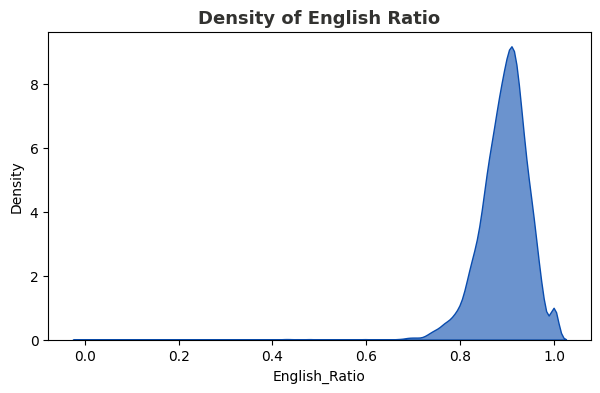

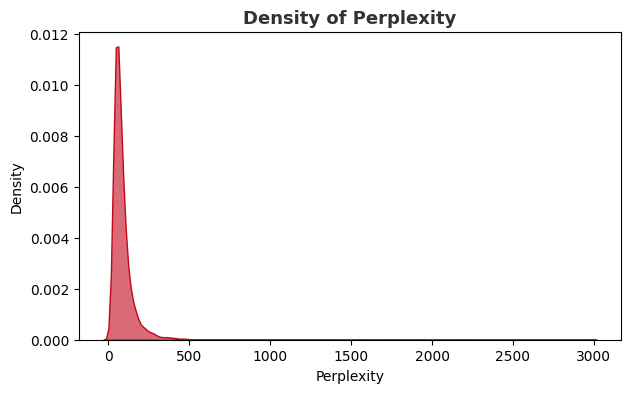

KeyError: 'Gibberish_Score'

<Figure size 700x400 with 0 Axes>

In [24]:
# Small batch
plot_density_metrics(batch_eng_perplexity)

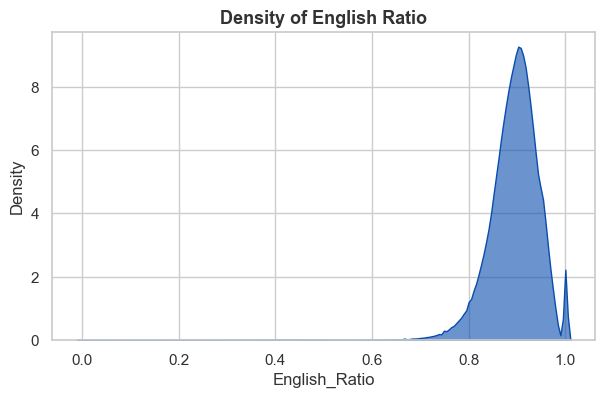

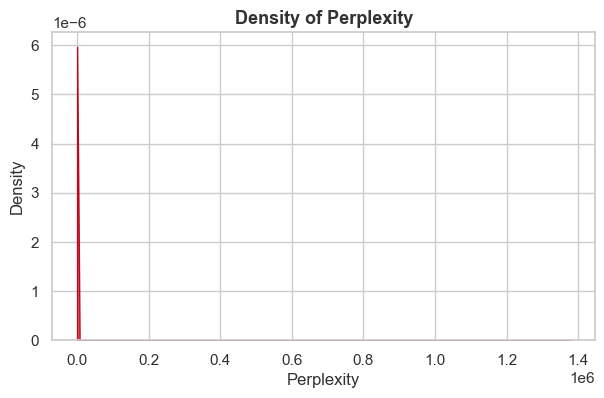

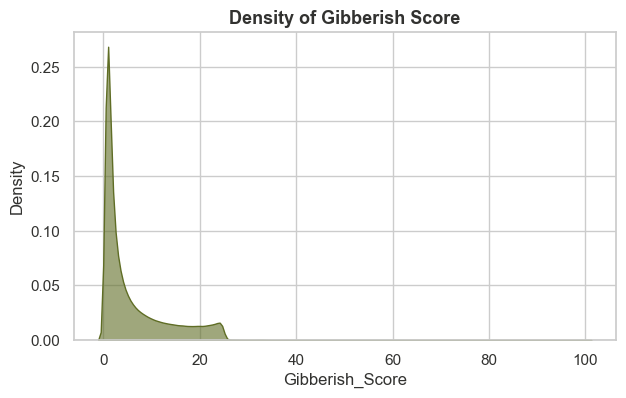

In [ ]:
# Whole training set
plot_density_metrics(train_eng_perplexity)

In [ ]:
test_Gibberish_Classification = test_eng_perplexity.copy()

The boundary of "meaningful comment"

In [ ]:
def classify_gibberish(df):
    df["Class"] = df.apply(
        lambda x: "Meaningful" if (
            x["Gibberish_Score"] < 35 and
            x["English_Ratio"] > 0.57 and
            x["Perplexity"] < 1500
        ) else "Noise",
        axis=1
    )
    print(df["Class"].value_counts())
    return df


In [ ]:
classify_gibberish(batch_Gibberish_Classification)

Class
Meaningful    9979
Noise           21
Name: count, dtype: int64


,label,title,text,text_len,word_count,avg_word_len,Gibberish_Score,English_Ratio,Perplexity,Class
462211,1,The worst kind of science writing,"There's about half a book on the influenza epidemic of 1918 here, the rest is cluttered up with meaningless information--the names of peoples' children, the colors of their eyes, the kinds of cars they drive, etc--who cares. This book could have used some serious editing. The history is cursory--there's actually very little described about the epidemic and its immediate and long term aftermath. The narrative is cluttered; the story moves along and then detours to describe the most irrelevant facts. The science is fairly light-weight, and not especially elucidating--you will learn very few facts about the flu in this book.",629.0,100,5.300000,0.785526,0.849057,56.067830,Meaningful
906600,2,Beautiful. Moving. Gorgeous.,"I'd like to transplant myself in a little home next to the sisters' house, it would be bliss. Beyond the absolutely stunning scenery and costuming, this is a bittersweet, lovely movie.",184.0,31,4.967742,0.466850,0.968750,63.915614,Meaningful
953710,1,Overrated Tripe,"When this first came out I thought it was embarrassing crap. Imagine someone ripping off Delaney and Bonnie! Now the passage of years confirms it. Sentimental, adolescent, heart-on-sleeve stupidity with pretty lousy guitar work -- all unmelodic fills w/ Clapton's new-found Stratocaster fixation. Yuk. There's more filler here -- crummy versions of blues classics -- than a rusted out Chevy. Everyone who knows anything knows that BLUES BREAKERS and the 1st CREAM were, essentially, IT for Clapton. Well, w/ the Arabic origins of LAYLA we now know that if Clapton's God, he must serve Allah, right? I thought that was Cat Stevens, in whose class Clapton must be considered. One of the records that ushered in the sickening indulgences of 70s rock and stomped on the legacy of the 60s. Oh, rhythm section's pretty good. Rock and roll for those who don't rock and roll, hence selection as one of the GREATS. Thank you ROLLING STONE, or whoever.",946.0,159,4.955975,12.604328,0.852761,134.808574,Meaningful
777548,1,Wayy too much musk,"This perfume has beautiful mid and top-notes, but is extremely musky in the low-notes. I walked into a room where someone was wearing it and was nearly knocked over. I couldn't smell my own perfume on myself anymore, as the fragrance was burned into my nostrils for a couple of hours. I am a perfume connoisseur, and I don't recommend this one because it's too ""loud.""",368.0,66,4.590909,3.329160,0.873239,32.490631,Meaningful
644707,2,A well put together book!,"Once I started reading this book, I could not put it down. Not only is Cruver's writing crisp and concise, but the book has a wide range of emotions to help you feel engaged throughout. It is scary, funny and sad all rolled into one reading experience. I watched Enron: The Smartest Guys in the Room and felt that didn't compare to reading this book. It's weird, you almost feel as if you are Cruver's friend, even if you have never met him based on the intimacy of this book. In all, a great read!",498.0,95,4.252632,0.764664,0.909091,40.082598,Meaningful
...,...,...,...,...,...,...,...,...,...,...
888331,2,Inspirational but deep,"I thought that this book was very inspirational, although at times a bit too deep for me. The last half is more self- help, while the first half went a little over my head. Overall, I felt great after I read it and still look over certain chapters when Im feeling low.",268.0,52,4.173077,0.591354,0.961538,59.319139,Meaningful
927680,2,Just as great as I remember..,"I bought this DVD to introduce Doug to my best friend's kids. They loved him and have watched the DVDs numerous times in the last month or so since I bought it. They noticed that the animation isn't up to par with today's cartoons, but they love them nonetheless. We can't wait to get Season 2 and 3 as well. I definitely recommend this great show on DVD.",355.0

In [ ]:
classify_gibberish(train_Gibberish_Classification)

Class
Meaningful    1045780
Noise            2796
Name: count, dtype: int64


,label,title,text,Gibberish_Score,English_Ratio,Perplexity,Class
0,2,Stuning even for the non-gamer,This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I have ever played it has the best music! It backs away from crude keyboarding and takes a fresher step with grate guitars and soulful orchestras. It would impress anyone who cares to listen! _,4.916961,0.783784,120.147955,Meaningful
1,2,The best soundtrack ever to anything.,"I'm reading a lot of reviews saying that this is the best 'game soundtrack' and I figured that I'd write a review to disagree a bit. This in my opinino is Yasunori Mitsuda's ultimate masterpiece. The music is timeless and I'm been listening to it for years now and its beauty simply refuses to fade.The price tag on this is pretty staggering I must say, but if you are going to buy any cd for this much money, this is the only one that I feel would be worth every penny.",0.813691,0.916667,31.164884,Meaningful
2,2,Amazing!,"This soundtrack is my favorite music of all time, hands down. The intense sadness of ""Prisoners of Fate"" (which means all the more if you've played the game) and hope in ""A Distant Promise"" and ""Girl who Stole the Star"" have been an important inspiration to me personally throughout my teen years. The higher energy tracks like ""Chrono Cross ~ Time's Scar~"", ""Time of the Dreamwatch"", and ""Chronomantique"" (indefinably remeniscent of Chrono Trigger) are all absolutely superb as well.This soundtrack is amazing music, probably the best of this composer's work (I haven't heard the Xenogears soundtrack, so I can't say for sure), and even if you've never played the game, it would be worth twice the price to buy it.I wish I could give it 6 stars.",1.170734,0.849624,43.369774,Meaningful
3,2,Excellent Soundtrack,"I truly like this soundtrack and I enjoy video game music. I have played this game and most of the music on here I enjoy and it's truly relaxing and peaceful.On disk one. my favorites are Scars Of Time, Between Life and Death, Forest Of Illusion, Fortress of Ancient Dragons, Lost Fragment, and Drowned Valley.Disk Two: The Draggons, Galdorb - Home, Chronomantique, Prisoners of Fate, Gale, and my girlfriend likes ZelbessDisk Three: The best of the three. Garden Of God, Chronopolis, Fates, Jellyfish sea, Burning Orphange, Dragon's Prayer, Tower Of Stars, Dragon God, and Radical Dreamers - Unstealable Jewel.Overall, this is a excellent soundtrack and should be brought by those that like video game music.Xander Cross",11.104782,0.825000,118.222136,Meaningful
4,2,"Remember, Pull Your Jaw Off The Floor After Hearing it","If you've played the game, you know how divine the music is! Every single song tells a story of the game, it's that good! The greatest songs are without a doubt, Chrono Cross: Time's Scar, Magical Dreamers: The Wind, The Stars, and Sea and Radical Dreamers: Unstolen Jewel. (Translation varies) This music is perfect if you ask me, the best it can be. Yasunori Mitsuda just poured his heart on and wrote it down on paper.",2.770231,0.835443,64.974230,Meaningful
...,...,...,...,...,...,...,...
1048571,2,It beats flimsy extension cords,"You can tell right away that this is a rugged, quality item. The thick shielding alone marks it as a durable piece of equipment. My UPS outlets were being crowded out by bulky power adapters, and this splitter cable came to the rescue.",10.610584,0.906977,101.233935,Meaningful
1048572,2,Does a great job.,"If you have 1-4 power bricks and only one outlet. This works great, and does something that a power strip can't do.",2.685576,0.954545,56.926959,Meaningful
1048573,2,Power Cable 1-4 Splitter.,Exactly what I was looking for at the office. Will take up fewer power connections for all those monitors. Packaged well and shipped quickly.,2.393140,0.833333,156.202565,Meaningful
1048574,2,"Very good, but ther

In [ ]:
classify_gibberish(test_Gibberish_Classification)

Class
Meaningful    398837
Noise           1163
Name: count, dtype: int64


,label,title,text,Gibberish_Score,English_Ratio,Perplexity,Class
0,2,Great CD,"My lovely Pat has one of the GREAT voices of her generation. I have listened to this CD for YEARS and I still LOVE IT. When I'm in a good mood it makes me feel better. A bad mood just evaporates like sugar in the rain. This CD just oozes LIFE. Vocals are jusat STUUNNING and lyrics just kill. One of life's hidden gems. This is a desert isle CD in my book. Why she never made it big is just beyond me. Everytime I play this, no matter black, white, young, old, male, female EVERYBODY says one thing ""Who was that singing ?""",10.177100,0.838095,84.634186,Meaningful
1,2,One of the best game music soundtracks - for a game I didn't really play,"Despite the fact that I have only played a small portion of the game, the music I heard (plus connection to Chrono Trigger which was great as well) led me to purchase the soundtrack, and it remains one of my favorite albums. There is an incredible mix of fun, epic, and emotional songs. Those sad and beautiful tracks I especially like, as there's not too many of those kinds of songs in my other video game soundtracks. I must admit that one of the songs (Life-A Distant Promise) has brought tears to my eyes on many occasions.My one complaint about this soundtrack is that they use guitar fretting effects in many of the songs, which I find distracting. But even if those weren't included I would still consider the collection worth it.",0.617633,0.860294,33.438843,Meaningful
2,1,Batteries died within a year ..,"I bought this charger in Jul 2003 and it worked OK for a while. The design is nice and convenient. However, after about a year, the batteries would not hold a charge. Might as well just get alkaline disposables, or look elsewhere for a charger that comes with batteries that have better staying power.",2.355080,0.905660,45.699530,Meaningful
3,2,"works fine, but Maha Energy is better","Check out Maha Energy's website. Their Powerex MH-C204F charger works in 100 minutes for rapid charge, with option for slower charge (better batteries). And they have 2200 mAh batteries.",14.446289,0.766667,215.022322,Meaningful
4,2,Great for the non-audiophile,"Reviewed quite a bit of the combo players and was hesitant due to unfavorable reviews and size of machines. I am weaning off my VHS collection, but don't want to replace them with DVD's. This unit is well built, easy to setup and resolution and special effects (no progressive scan for HDTV owners) suitable for many people looking a versatile product.Cons- No universal remote.",8.815552,0.835821,147.470973,Meaningful
...,...,...,...,...,...,...,...
399995,1,Unbelievable- In a Bad Way,"We bought this Thomas for our son who is a huge Thomas fan, and has a huge set up in his room. He has both the Thomas(this product, bought somewhere else) and the Percy model. The Thomas we had stopped working, and was a older model, so we bought this one to replace it. Our son was very upset when we had to retire his older Thomas, but we promised him a new one.We bought this product, and waited patiently to add it to our son's Thomas collection. When it came, we opened it right away, and were shocked when we were looking at the Percy instead of Thomas.We coulda/woulda/shoulda contacted the seller, but this ""Thomas"" product is already in our Tildsmen shed, since we opened the package with our son.With so many places to buy genuine Thomas gear, if you are paying the premium Thomas price, we expected a better product experience.",10.283018,0.912500,51.754124,Meaningful
399996,1,"Almost Great, Until it Broke..","My son recieved this as a birthday gift 2 months ago. He LOVED it even though it didn't corner well on our Mellissa and Doug train track. He mostly let it run on the floor, not the track, so that wasn't that big of an issue. It did, however, break after one fall from counter height. My son let it drive off the kitchen counter and after only 2 short months it is officially broken. It can still 

Visualisation for Meaningful/Noise comment

In [ ]:
train_sampled_10pct = train_Gibberish_Classification.sample(
    frac = 0.1,
    random_state = 415)

In [ ]:
test_sampled_10pct = test_Gibberish_Classification.sample(
    frac = 0.1,
    random_state = 415)

In [ ]:
import plotly.express as px
import numpy as np

def Visualisation_3D(df, log_perplexity=False):
    # Force light theme to avoid dark mode in Jupyter or VS Code
    template_style = "plotly"

    if not log_perplexity:
        # 3D scatter plot using raw Perplexity
        fig = px.scatter_3d(
            df,
            x="English_Ratio",
            y="Perplexity",
            z="Gibberish_Score",
            color="Class",
            color_discrete_map={
                "Meaningful": "#094cae",
                "Noise": "#c1071b"
            },
            hover_data={
                "text": True if "text" in df.columns else False,
                "English_Ratio": ':.3f',
                "Perplexity": ':.3f',
                "Gibberish_Score": ':.2f',
                "Class": True
            },
            title="Meaningful vs Noise — English Ratio × Perplexity × Gibberish Score",
            template=template_style
        )

        # Visual settings
        fig.update_traces(marker=dict(size=4, opacity=0.8))
        fig.update_layout(
            scene=dict(
                xaxis_title="English Ratio",
                yaxis_title="Perplexity",
                zaxis_title="Gibberish Score (0–100)",
                xaxis=dict(backgroundcolor="rgb(245,245,245)"),
                yaxis=dict(backgroundcolor="rgb(245,245,245)"),
                zaxis=dict(backgroundcolor="rgb(245,245,245)")
            ),
            legend_title_text="Text Type",
            legend=dict(
                itemsizing='constant',
                bgcolor='rgba(255,255,255,0.75)',
                bordercolor='rgba(0,0,0,0.1)',
                borderwidth=1
            ),
            width=950,
            height=750,
            margin=dict(l=0, r=0, b=0, t=50)
        )

        fig.show()

    else:
        # Apply log transform to Perplexity
        df["log_Perplexity"] = np.log1p(df["Perplexity"])

        # 3D scatter plot with log-transformed Perplexity
        fig = px.scatter_3d(
            df,
            x="English_Ratio",
            y="log_Perplexity",
            z="Gibberish_Score",
            color="Class",
            color_discrete_map={
                "Meaningful": "#094cae",
                "Noise": "#c1071b"
            },
            hover_data={
                "text": True if "text" in df.columns else False,
                "English_Ratio": ':.3f',
                "log_Perplexity": ':.3f',
                "Gibberish_Score": ':.2f',
                "Class": True
            },
            title="Meaningful vs Noise — English Ratio × log(Perplexity) × Gibberish Score",
            template=template_style
        )

        # Visual settings for log view
        fig.update_traces(marker=dict(size=4, opacity=0.8))
        fig.update_layout(
            scene=dict(
                xaxis_title="English Ratio",
                yaxis_title="log(Perplexity + 1)",
                zaxis_title="Gibberish Score (0–100)",
                xaxis=dict(backgroundcolor="rgb(245,245,245)"),
                yaxis=dict(backgroundcolor="rgb(245,245,245)"),
                zaxis=dict(backgroundcolor="rgb(245,245,245)")
            ),
            legend_title_text="Text Type",
            legend=dict(
                itemsizing='constant',
                bgcolor='rgba(255,255,255,0.75)',
                bordercolor='rgba(0,0,0,0.1)',
                borderwidth=1
            ),
            width=950,
            height=750,
            margin=dict(l=0, r=0, b=0, t=50)
        )

        fig.show()


In [ ]:
Visualisation_3D(train_sampled_10pct, log_perplexity=False)

In [ ]:
# Take log for the perplexity
Visualisation_3D(train_sampled_10pct, log_perplexity=True)

In [ ]:
# For testing set
Visualisation_3D(test_sampled_10pct, log_perplexity=True)

In [ ]:
train_sampled_10pct

,label,title,text,Gibberish_Score,English_Ratio,Perplexity,Class
903656,1,Claim,"What a review? Though I placed an order for men's Casio divers watch on Sept. 19, 2007, I have not yet received it from you or Chelsea Watches.I paid U$67.00 for the watch on the same day. So far I have not received the watch or your refund.",9.002244,0.895833,59.714069,Meaningful
894228,1,IT DOESN'T WORK IN CASIO POCKET PC E-115,I TRIED THIS WITH TWO PRETEC MODEMS AND TECK SUPPORTS FROM CASIO AND PRETEC IT WASN'T RECOGNIZED. I'M GOING TO TRY THE CASIO MODEM,21.675369,0.653846,66.907525,Meaningful
11669,2,Every man needs it,I believe every mens group should study this book. I know everyone who reads this book will see a bit of himself somewhere while reading it. I will be taking this with me to my next mens group and i will make sure our group studies it.I enjoyed reading about David's Mighty Men. How great would it be if we all had our own group of Mighty Men to encourage us through the battles of life. How much better would it be if we were asked to be a Mighty Man for someone else. A great book.,1.190786,0.929293,38.553225,Meaningful
82755,1,"Good itea, but..","I like the idea that the blinds hang on a standard curtain pole, so you don't have to fuss around with mounting. However, the selection is slim, and I don't think you can even find these anymore. I did order the natural/ivory color, but they are not lined and don't keep out the light at night, when I want the bedroom to be DARK. I also have a pair in dark purple, which blocks the light better. I agree that you have to be very careful raising and lowering them, the mechanism is rather flimsy.",1.962458,0.959596,49.530215,Meaningful
531823,2,Reliable and Convenient,"Utilized these for our stairs and they work very well. I was surprised how nice they looked once they arrived. Being able to utilize a step to unlatch the gate is very nice to have, seeing as our kid or some other object seems to be in our hands every time we go up and down the stairs.However, we required two extensions on each of the gates we purchased in order to get to the appropriate width for our staircases so I would recommend making sure you measure your stairs before ordering this gate and the necessary extensions.",4.096822,0.838384,52.934304,Meaningful
...,...,...,...,...,...,...,...
224850,2,For a Basset Hound,I have a 45 lb Basset Hound and if you have ever had one they stink to high heaven. Must be that special Basset Hound perfume. Having these dog wipes keeps that under control. I have to wipe out the folds in her neck and also her ears to make sure that the odor does not overtake the whole house. You sure know when she walks into a room. Haha She is such a cutey though that I will keep her and just make sure she is clean. Basset Hounds are hilarious.,0.991846,0.890110,69.304289,Meaningful
90934,1,Shouldn't Reading Be Fun?,"This is so wordy and difficult to read, that it wasn't even worth finishing. I was VERY disappointed in this author, since I usually enjoy his writing.",0.438975,0.964286,37.340252,Meaningful
377843,1,"Not a ""How To"" book","Falls short if you are looking for a step by step guide on how to implement a Home Network. Very little discussion about statis IP connections, using routers or printservers.Primarily includes descriptions of various technologies as well as advantages and disavantages.Troubleshooting section consists of recommendations to contact someone who knows networking and references to websites to go for assistance.",14.909420,0.688525,182.538334,Meaningful
415358,2,just ok,"i use this monitor for cad, and after using other viewsonics, this one is pretty darn good. lines and text are all very sharp using the native resolution of 1280x1024. i would have given it 5 stars if it wasn't for one bright green dead pixel, and a more discrite one darker and off to the side. from reading other reviews, it seems to be common for this monitor",3.343285,0.840580,96.612191,Meaningful
